In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [16]:
exportar = False
exportar = True

# Un solo switch para que todo el flujo use franchise + grade.
# Cambiar a False reproduce la lógica original solo por franchise.
USE_GRADE = True


### raw franchise-store-dow-block

In [17]:
from google.colab import drive
drive.mount('/content/drive')
file_name = 'all_restaurants.csv'
file_name = 'all_restaurants_plus.csv'
file_name = 'manuales.csv'
file_name = 'niu_conce.csv'
file_name = 'W28-39_0fir_franchises_grades.csv'

file_path_main = '/content/drive/MyDrive/lower ept y awt/ept reductions input data/'
file_path = file_path_main + file_name
df = pd.read_csv(file_path)
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,franchise_id,franchise_name,city_name,vertical_type,grade,franchise_orders,franchise_stores,franchise_orders_with_fir,franchise_fir,vendor_code,store_name,store_orders_total,store_orders_with_fir,store_fir,day_of_week_num,day_of_week_name,time_block,total_orders,slow_orders,non_seamless_orders,hd_total_orders,hd_total_minutes_added,started_triggers,avg_trigger_duration_min,orders_with_fir,fir_ratio,ept,awt,tt,ctp,fir
0,0011r00002VoIKjAAN,Buffet Express,Antofagasta,restaurants,A,3768,27,17,0.0045,66494,Buffet Express Antofagasta,406,0,0.0,1,Sunday,lunch,50,9,10,1,8,1,1200.0,0,0.0,18.90,5.60,24.50,29.5,NaN
1,0011r00002VoIKjAAN,Buffet Express,Antofagasta,restaurants,A,3768,27,17,0.0045,66494,Buffet Express Antofagasta,406,0,0.0,1,Sunday,dinner,1,0,0,0,0,0,NaN,0,0.0,15.00,1.60,16.60,16.0,NaN
2,0011r00002VoIKjAAN,Buffet Express,Antofagasta,restaurants,A,3768,27,17,0.0045,66494,Buffet Express Antofagasta,406,0,0.0,1,Sunday,valle,23,3,6,3,24,2,750.0,0,0.0,16.43,4.77,21.21,26.3,NaN


In [18]:
file_path_external = '/content/drive/MyDrive/lower ept y awt/deprecated/impact_measure.xlsx'
reductions = pd.read_excel(file_path_external, sheet_name='all_reductions')

to_reduct = list(reductions['vendor_code'].unique())
reductions.head(1)

,wave,franchise_name,vendor_code,store_name,ept_min,reduction,new_ept_min,diff
0,W1,China Wok,52045,China Wok Costanera Center,29.0,0.47,14.0,-15.0


### df_grouped: Data agregada por franchise-store

In [19]:
import numpy as np

def wavg(x, value_col, weight_col='total_orders'):
    """
    Promedio ponderado usando únicamente filas con valor y peso válidos.
    """
    values = pd.to_numeric(x[value_col], errors='coerce')
    weights = pd.to_numeric(x[weight_col], errors='coerce')

    mask = values.notna() & weights.notna() & (weights > 0)

    if not mask.any() or weights.loc[mask].sum() == 0:
        return np.nan

    return np.average(
        values.loc[mask],
        weights=weights.loc[mask]
    )


def weighted_total(x, value_col, weight_col='total_orders'):
    """
    Convierte un promedio por fila en volumen total:
        sum(value * weight)
    """
    values = pd.to_numeric(x[value_col], errors='coerce')
    weights = pd.to_numeric(x[weight_col], errors='coerce')

    mask = values.notna() & weights.notna() & (weights > 0)

    if not mask.any():
        return 0.0

    return (values.loc[mask] * weights.loc[mask]).sum()

In [20]:
df_for_grouping = df.copy()

if USE_GRADE and 'grade' not in df_for_grouping.columns:
    raise KeyError(
        "USE_GRADE=True requiere una columna 'grade' en el CSV de entrada. "
        "Agrégala en la query con una sola grade vigente por vendor_code."
    )

# Preservar grade en la granularidad vendor cuando venga en la fuente.
# Los valores vacíos forman su propio grupo para no perder órdenes.
if 'grade' in df_for_grouping.columns:
    df_for_grouping['grade'] = (
        df_for_grouping['grade']
        .fillna('NO_GRADE')
        .astype(str)
        .str.strip()
        .replace({'': 'NO_GRADE', 'nan': 'NO_GRADE', 'None': 'NO_GRADE'})
    )

    vendor_grade_count = (
        df_for_grouping
        .groupby('vendor_code', dropna=False)['grade']
        .nunique(dropna=False)
    )

    vendors_with_multiple_grades = vendor_grade_count[
        vendor_grade_count > 1
    ]

    if not vendors_with_multiple_grades.empty:
        raise ValueError(
            "Cada vendor_code debe tener una sola grade vigente. "
            "Vendors con más de una: "
            f"{vendors_with_multiple_grades.index.astype(str).tolist()[:20]}"
        )

group_cols = [
    'franchise_id',
    'franchise_name',
    'city_name',
    'vendor_code',
    'store_name'
]

if 'grade' in df_for_grouping.columns:
    group_cols.insert(2, 'grade')

df_grouped = (
    df_for_grouping
    .groupby(group_cols, as_index=False, dropna=False)
    .apply(lambda x: pd.Series({
        'franchise_orders': x['franchise_orders'].iloc[0],
        'franchise_stores': x['franchise_stores'].iloc[0],
        'store_orders_total': x['store_orders_total'].iloc[0],

        # Volúmenes
        'total_orders': x['total_orders'].sum(),
        'slow_orders': x['slow_orders'].sum(),
        'non_seamless_orders': x['non_seamless_orders'].sum(),
        'orders_with_fir': x['orders_with_fir'].sum(),

        # HDM
        # En la data raw la columna se llama hd_total_orders.
        'hd_orders': x['hd_total_orders'].sum(),
        'hd_total_minutes_added': x['hd_total_minutes_added'].sum(),

        # Total de minutos EPT antes de quitar HDM.
        'ept_total_minutes': weighted_total(
            x,
            value_col='ept',
            weight_col='total_orders'
        ),

        # Promedios
        'ept': wavg(x, 'ept', 'total_orders'),
        'awt': wavg(x, 'awt', 'total_orders'),
        'tt': wavg(x, 'tt', 'total_orders'),

        # FIR promedio entre las órdenes que efectivamente tienen FIR.
        # No se pondera por total_orders, sino por orders_with_fir.
        'fir': wavg(x, 'fir', 'orders_with_fir'),

        'ctp': wavg(x, 'ctp', 'total_orders')
    }), include_groups=False)
    .reset_index(drop=True)
)

df_grouped['slow_ratio'] = np.where(
    df_grouped['total_orders'] > 0,
    df_grouped['slow_orders'] / df_grouped['total_orders'],
    np.nan
)

df_grouped['non_seamless_ratio'] = np.where(
    df_grouped['total_orders'] > 0,
    df_grouped['non_seamless_orders'] / df_grouped['total_orders'],
    np.nan
)

# FIR ratio del vendor: share de órdenes que tienen FIR.
df_grouped['fir_ratio'] = np.where(
    df_grouped['total_orders'] > 0,
    df_grouped['orders_with_fir'] / df_grouped['total_orders'],
    np.nan
)

# Nombre explícito para el FIR promedio en minutos.
df_grouped['fir_avg'] = df_grouped['fir']

# EPT promedio quitando los minutos agregados por HDM:
# (sum(ept * total_orders) - sum(hd_total_minutes_added)) / sum(total_orders)
df_grouped['avg_ept_sin_hdm'] = np.where(
    df_grouped['total_orders'] > 0,
    (
        df_grouped['ept_total_minutes']
        - df_grouped['hd_total_minutes_added']
    ) / df_grouped['total_orders'],
    np.nan
)

# Control: diferencia promedio explicada por HDM.
df_grouped['avg_hdm_minutes_per_order'] = np.where(
    df_grouped['total_orders'] > 0,
    df_grouped['hd_total_minutes_added'] / df_grouped['total_orders'],
    np.nan
)

# Controles calculados desde la propia base. En modo grade se usan para
# filtrar grupos franchise-grade con suficiente cantidad de stores.
df_grouped['franchise_stores_calc'] = (
    df_grouped
    .groupby('franchise_id')['vendor_code']
    .transform('nunique')
)

if 'grade' in df_grouped.columns:
    franchise_grade_keys = ['franchise_id', 'grade']
    df_grouped['franchise_grade_stores_calc'] = (
        df_grouped
        .groupby(franchise_grade_keys)['vendor_code']
        .transform('nunique')
    )
    df_grouped['franchise_grade_orders_calc'] = (
        df_grouped
        .groupby(franchise_grade_keys)['total_orders']
        .transform('sum')
    )

sort_cols = ['franchise_name']
if 'grade' in df_grouped.columns:
    sort_cols.append('grade')
sort_cols += ['store_name', 'city_name']

df_grouped = df_grouped.sort_values(sort_cols).reset_index(drop=True)

df_grouped['ept_raw'] = df_grouped['ept']
df_grouped['ept'] = df_grouped['avg_ept_sin_hdm']
df_grouped_raw = df_grouped.copy()
df_grouped_raw.head(3)


,franchise_id,franchise_name,grade,city_name,vendor_code,store_name,franchise_orders,franchise_stores,store_orders_total,total_orders,slow_orders,non_seamless_orders,orders_with_fir,hd_orders,hd_total_minutes_added,ept_total_minutes,ept,awt,tt,fir,ctp,slow_ratio,non_seamless_ratio,fir_ratio,fir_avg,avg_ept_sin_hdm,avg_hdm_minutes_per_order,franchise_stores_calc,franchise_grade_stores_calc,franchise_grade_orders_calc,ept_raw
0,0011r00002VoIKjAAN,Buffet Express,A,Antofagasta,66494,Buffet Express Antofagasta,3768.0,27.0,406.0,406.0,68.0,99.0,0.0,31.0,244.0,6708.87,15.923325,4.917143,21.441305,NaN,26.319631,0.167488,0.243842,0.0,NaN,15.923325,0.600985,27,3,1236.0,16.524310
1,0011r00002VoIKjAAN,Buffet Express,A,Calama,105139,Buffet Express Calama,3768.0,27.0,481.0,481.0,12.0,63.0,0.0,58.0,448.0,5408.13,10.312121,2.647854,13.898062,NaN,15.466778,0.024948,0.130977,0.0,NaN,10.312121,0.931393,27,3,1236.0,11.243514
2,0011r00002VoIKjAAN,Buffet Express,A,Valdivia,66490,Buffet Express Valdivia,3768.0,27.0,349.0,349.0,7.0,46.0,0.0,14.0,100.0,3716.33,10.361977,3.347077,13.995415,NaN,15.208510,0.020057,0.131805,0.0,NaN,10.361977,0.286533,27,3,1236.0,10.648510


In [21]:
ept_actuales = df.copy()
ept_actuales.head(3) # agregar a query los filtros de la query anterior, incluir city_name, slow_orders, non_seamless_orders, ctp

,franchise_id,franchise_name,city_name,vertical_type,grade,franchise_orders,franchise_stores,franchise_orders_with_fir,franchise_fir,vendor_code,store_name,store_orders_total,store_orders_with_fir,store_fir,day_of_week_num,day_of_week_name,time_block,total_orders,slow_orders,non_seamless_orders,hd_total_orders,hd_total_minutes_added,started_triggers,avg_trigger_duration_min,orders_with_fir,fir_ratio,ept,awt,tt,ctp,fir
0,0011r00002VoIKjAAN,Buffet Express,Antofagasta,restaurants,A,3768,27,17,0.0045,66494,Buffet Express Antofagasta,406,0,0.0,1,Sunday,lunch,50,9,10,1,8,1,1200.0,0,0.0,18.90,5.60,24.50,29.5,NaN
1,0011r00002VoIKjAAN,Buffet Express,Antofagasta,restaurants,A,3768,27,17,0.0045,66494,Buffet Express Antofagasta,406,0,0.0,1,Sunday,dinner,1,0,0,0,0,0,NaN,0,0.0,15.00,1.60,16.60,16.0,NaN
2,0011r00002VoIKjAAN,Buffet Express,Antofagasta,restaurants,A,3768,27,17,0.0045,66494,Buffet Express Antofagasta,406,0,0.0,1,Sunday,valle,23,3,6,3,24,2,750.0,0,0.0,16.43,4.77,21.21,26.3,NaN


## funciones

median_cap()

In [22]:
def median_cap(
    df,
    value_col="ept_new",
    weight_col="total_orders",
    group_col="vendor_code",
    percentile=50,
    multiplier=1.2
):
    """
    Capea value_col a multiplier * weighted_percentile(group).

    Retorna una copia del dataframe con:
        - vendor_percentile
        - upper_limit
        - is_capped
        - value_col modificado
    """

    new_df = df.copy()

    percentile_df = (
        new_df
        .groupby(group_col)
        .apply(
            lambda x: weighted_percentile(
                x,
                value_col,
                weight_col,
                percentile
            ),
            include_groups=False
        )
        .reset_index(name="vendor_percentile")
    )

    new_df = new_df.merge(
        percentile_df,
        on=group_col,
        how="left"
    )

    new_df["upper_limit"] = (
        new_df["vendor_percentile"] * multiplier
    )

    new_df["is_capped"] = (
        new_df[value_col] > new_df["upper_limit"]
    )

    new_df[value_col] = np.where(
        new_df["is_capped"],
        new_df["upper_limit"],
        new_df[value_col]
    )

    print(f"Number of rows capped: {new_df['is_capped'].sum():,}")

    return new_df

### simulate_ept_reduction()

In [23]:
import pandas as pd
import numpy as np

def simulate_ept_reduction(
    df,
    pct_orders=30,
    percentil=50,
    include_stores=None,
    pre_selected=None,
    median_multiply_by=1,
    grade=True
):
    """
    Selecciona vendors ordenados DESC por TT hasta cubrir pct_orders% de
    las órdenes de cada grupo.

    - grade=True: el grupo es franchise_id + grade.
    - grade=False: el grupo es solo franchise_id (lógica original).

    A los vendors seleccionados y elegibles les asigna ept_new igual al
    percentil de EPT del mismo grupo. Un vendor es elegible si la reducción
    es de al menos 3 minutos y fir_ratio <= 0.8.

    Retorna:
      - new_df: detalle vendor con la simulación
      - summary: resumen por grupo sobre todos los vendors
      - summary_selected: resumen por grupo solo sobre los seleccionados
    """

    if not 0 <= pct_orders <= 100:
        raise ValueError("pct_orders debe estar entre 0 y 100")

    if not 0 <= percentil <= 100:
        raise ValueError("percentil debe estar entre 0 y 100")

    required_cols = {
        "franchise_id", "franchise_name", "vendor_code",
        "total_orders", "orders_with_fir", "fir_ratio",
        "ept", "awt", "tt"
    }

    if grade:
        required_cols.add("grade")

    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(
            "Faltan columnas requeridas para simulate_ept_reduction: "
            f"{missing_cols}"
        )

    new_df = df.copy()

    if grade:
        new_df["grade"] = (
            new_df["grade"]
            .fillna("NO_GRADE")
            .astype(str)
            .str.strip()
            .replace({"": "NO_GRADE", "nan": "NO_GRADE", "None": "NO_GRADE"})
        )

        vendor_grade_count = (
            new_df
            .groupby("vendor_code", dropna=False)["grade"]
            .nunique(dropna=False)
        )
        vendors_with_multiple_grades = vendor_grade_count[
            vendor_grade_count > 1
        ]

        if not vendors_with_multiple_grades.empty:
            raise ValueError(
                "grade=True requiere una sola grade por vendor_code. "
                "Vendors con más de una: "
                f"{vendors_with_multiple_grades.index.astype(str).tolist()[:20]}"
            )

    numeric_cols = [
        "total_orders",
        "orders_with_fir",
        "fir_ratio",
        "ept",
        "awt",
        "tt"
    ]

    for col in numeric_cols:
        new_df[col] = pd.to_numeric(new_df[col], errors="coerce")

    new_df = new_df.dropna(
        subset=["total_orders", "ept", "awt", "tt"]
    )
    new_df = new_df[new_df["total_orders"] > 0].copy()

    if new_df.empty:
        raise ValueError(
            "No quedan filas válidas después de exigir métricas y "
            "total_orders > 0."
        )

    selection_keys = ["franchise_id"]
    summary_keys = ["franchise_id", "franchise_name"]

    if grade:
        selection_keys.append("grade")
        summary_keys.append("grade")

    group_label = "franchise + grade" if grade else "franchise"
    q = percentil / 100

    # Percentiles dentro del grupo de selección.
    new_df["franchise_percentile_ept"] = (
        new_df
        .groupby(selection_keys, dropna=False)["ept"]
        .transform(lambda x: x.quantile(q))
        * median_multiply_by
    )

    new_df["franchise_percentile_tt"] = (
        new_df
        .groupby(selection_keys, dropna=False)["tt"]
        .transform(lambda x: x.quantile(q))
    )

    # Orden y posiciones dentro de franchise o franchise-grade.
    new_df = new_df.sort_values(
        selection_keys + ["tt"],
        ascending=[True] * len(selection_keys) + [False]
    ).copy()

    new_df["position_in_selection_group_by_tt"] = (
        new_df
        .groupby(selection_keys, dropna=False)["tt"]
        .rank(method="first", ascending=False)
    )

    new_df["tt_percentile_rank_in_selection_group"] = (
        new_df
        .groupby(selection_keys, dropna=False)["tt"]
        .rank(method="average", pct=True) * 100
    )

    # Alias para no romper usos anteriores del notebook.
    new_df["position_in_franchise_by_tt"] = (
        new_df["position_in_selection_group_by_tt"]
    )
    new_df["tt_percentile_rank_in_franchise"] = (
        new_df["tt_percentile_rank_in_selection_group"]
    )

    # El total real de franchise se conserva como control; el threshold
    # usa selection_group_orders_calc, que separa grade cuando corresponde.
    new_df["franchise_orders_calc"] = (
        new_df
        .groupby("franchise_id", dropna=False)["total_orders"]
        .transform("sum")
    )

    new_df["selection_group_orders_calc"] = (
        new_df
        .groupby(selection_keys, dropna=False)["total_orders"]
        .transform("sum")
    )

    new_df["cum_orders"] = (
        new_df
        .groupby(selection_keys, dropna=False)["total_orders"]
        .cumsum()
    )

    new_df["cum_orders_before"] = (
        new_df["cum_orders"] - new_df["total_orders"]
    )

    new_df["target_orders"] = (
        new_df["selection_group_orders_calc"] * (pct_orders / 100)
    )

    if pre_selected is None:
        pre_selected = []

    if include_stores is None:
        include_stores = []

    if len(pre_selected) > 0:
        pre_selected_str = {str(x) for x in pre_selected}
        new_df["is_selected"] = (
            new_df["vendor_code"].astype(str).isin(pre_selected_str)
        )
    else:
        # Incluye el vendor que cruza el threshold.
        new_df["is_selected"] = (
            new_df["cum_orders_before"] < new_df["target_orders"]
        )

    include_stores_str = {str(x) for x in include_stores}
    if include_stores_str:
        new_df["is_selected"] = (
            new_df["vendor_code"].astype(str).isin(include_stores_str)
            | new_df["is_selected"]
        )

    if pct_orders == 0:
        new_df["is_selected"] = False

    # Una sola máscara evita marcar como selected a un vendor cuyo EPT
    # finalmente no cambió por FIR alto u otra restricción.
    effective_reduction = (
        new_df["is_selected"]
        & (
            new_df["franchise_percentile_ept"]
            <= new_df["ept"] - 3
        )
        & (new_df["fir_ratio"] <= 0.8)
    )

    new_df["ept_new"] = np.where(
        effective_reduction,
        new_df["franchise_percentile_ept"],
        new_df["ept"]
    )
    new_df["is_selected"] = effective_reduction

    new_df["ept_reduction_mins"] = (
        new_df["ept_new"] - new_df["ept"]
    )
    new_df["ept_reduction_pct"] = np.where(
        new_df["ept"] > 0,
        1 - (new_df["ept_new"] / new_df["ept"]),
        np.nan
    )

    before_global = np.average(
        new_df["ept"],
        weights=new_df["total_orders"]
    )
    after_global = np.average(
        new_df["ept_new"],
        weights=new_df["total_orders"]
    )

    delta_global = after_global - before_global
    pct_delta_global = (
        delta_global / before_global * 100
        if before_global != 0 else np.nan
    )

    print(
        f"Selected top vendors until covering {pct_orders}% of orders "
        f"per {group_label}"
    )
    print(f"Before w-avg ept: {before_global:.2f} min")
    print(f"After w-avg ept:  {after_global:.2f} min")
    print(f"Reduction: {-delta_global:.2f} min ({-pct_delta_global:.2f}%)")

    def weighted_avg(g, value_col):
        valid = (
            g[value_col].notna()
            & g["total_orders"].notna()
            & (g["total_orders"] > 0)
        )
        if not valid.any():
            return np.nan
        return np.average(
            g.loc[valid, value_col],
            weights=g.loc[valid, "total_orders"]
        )

    # Resumen sobre todos los vendors del grupo.
    summary = (
        new_df
        .groupby(summary_keys, as_index=False, dropna=False)
        .apply(lambda g: pd.Series({
            "stores": g["vendor_code"].nunique(),
            "selected_stores": (
                g.loc[g["is_selected"], "vendor_code"].nunique()
            ),
            "orders": g["total_orders"].sum(),
            "fir_ratio": (
                g["orders_with_fir"].sum() / g["total_orders"].sum()
                if g["total_orders"].sum() > 0 else np.nan
            ),
            "selected_orders": (
                g.loc[g["is_selected"], "total_orders"].sum()
            ),
            "selected_order_share_pct": (
                g.loc[g["is_selected"], "total_orders"].sum()
                / g["total_orders"].sum()
                * 100
                if g["total_orders"].sum() > 0 else np.nan
            ),
            "median_ept_min": g["ept"].median(),
            "franchise_percentile_ept": (
                g["franchise_percentile_ept"].iloc[0]
            ),
            "before_ept": weighted_avg(g, "ept"),
            "after_ept": weighted_avg(g, "ept_new")
        }), include_groups=False)
        .reset_index(drop=True)
    )

    summary["reduction_min"] = (
        summary["before_ept"] - summary["after_ept"]
    )
    summary["reduction_pct"] = np.where(
        summary["before_ept"] > 0,
        summary["reduction_min"] / summary["before_ept"] * 100,
        np.nan
    )
    summary = summary.sort_values(
        "reduction_min", ascending=False
    ).reset_index(drop=True)

    # Resumen solo sobre vendors con reducción efectiva.
    selected_df = new_df[new_df["is_selected"]].copy()
    selected_summary_cols = summary_keys + [
        "selected_stores",
        "selected_orders",
        "fir_ratio",
        "before_ept_selected",
        "after_ept_selected",
        "franchise_percentile_ept",
        "ept_reduction_min_selected",
        "ept_reduction_pct_selected"
    ]

    if selected_df.empty:
        summary_selected = pd.DataFrame(
            columns=selected_summary_cols
        )
    else:
        summary_selected = (
            selected_df
            .groupby(summary_keys, as_index=False, dropna=False)
            .apply(lambda g: pd.Series({
                "selected_stores": g["vendor_code"].nunique(),
                "selected_orders": g["total_orders"].sum(),
                "fir_ratio": (
                    g["orders_with_fir"].sum() / g["total_orders"].sum()
                    if g["total_orders"].sum() > 0 else np.nan
                ),
                "before_ept_selected": weighted_avg(g, "ept"),
                "after_ept_selected": weighted_avg(g, "ept_new"),
                "franchise_percentile_ept": (
                    g["franchise_percentile_ept"].iloc[0]
                )
            }), include_groups=False)
            .reset_index(drop=True)
        )

        summary_selected["ept_reduction_min_selected"] = (
            summary_selected["before_ept_selected"]
            - summary_selected["after_ept_selected"]
        )
        summary_selected["ept_reduction_pct_selected"] = np.where(
            summary_selected["before_ept_selected"] > 0,
            summary_selected["ept_reduction_min_selected"]
            / summary_selected["before_ept_selected"] * 100,
            np.nan
        )
        summary_selected = summary_selected.sort_values(
            "ept_reduction_min_selected",
            ascending=False
        ).reset_index(drop=True)

    return new_df, summary, summary_selected


### aplicar_factor_ept()

In [24]:
import numpy as np
import pandas as pd

def aplicar_factor_ept(ept_actuales, df_reduction, grade=False):
    """
    Aplica el factor de reducción al detalle original.

    Con grade=True el merge se valida y realiza por vendor_code + grade.
    Esto evita cruces incorrectos si la fuente llegara a contener el mismo
    vendor asociado a más de una grade.
    """

    df_out = ept_actuales.copy()

    store_col = "vendor_code"
    ept_col = "ept"
    reduction_col = "ept_reduction_pct"
    merge_cols = [store_col]

    if grade:
        merge_cols.append("grade")

    missing_out = sorted(set(merge_cols + [ept_col]) - set(df_out.columns))
    missing_reduction = sorted(
        set(merge_cols + [reduction_col]) - set(df_reduction.columns)
    )

    if missing_out:
        raise KeyError(
            f"Faltan columnas en ept_actuales: {missing_out}"
        )
    if missing_reduction:
        raise KeyError(
            f"Faltan columnas en df_reduction: {missing_reduction}"
        )

    df_out[store_col] = df_out[store_col].astype(str)
    factors = df_reduction[merge_cols + [reduction_col]].copy()
    factors[store_col] = factors[store_col].astype(str)

    if grade:
        for frame in (df_out, factors):
            frame["grade"] = (
                frame["grade"]
                .fillna("NO_GRADE")
                .astype(str)
                .str.strip()
                .replace({
                    "": "NO_GRADE",
                    "nan": "NO_GRADE",
                    "None": "NO_GRADE"
                })
            )

    factors[reduction_col] = pd.to_numeric(
        factors[reduction_col], errors="coerce"
    )

    # Si viene como 13 en vez de 0.13, lo transforma a 0.13.
    factors[reduction_col] = np.where(
        factors[reduction_col] > 1,
        factors[reduction_col] / 100,
        factors[reduction_col]
    )

    reductions_per_key = (
        factors
        .groupby(merge_cols, dropna=False)[reduction_col]
        .nunique(dropna=True)
    )
    conflicting_keys = reductions_per_key[reductions_per_key > 1]

    if not conflicting_keys.empty:
        raise ValueError(
            "Hay más de un factor de reducción para la misma llave "
            f"{merge_cols}: {conflicting_keys.index.tolist()[:20]}"
        )

    factors = (
        factors
        .drop_duplicates(subset=merge_cols)
        .rename(columns={
            reduction_col: "ept_reduction_pct_applied"
        })
    )

    df_out = df_out.merge(
        factors,
        on=merge_cols,
        how="left",
        validate="many_to_one"
    )

    # Vendors sin reducción explícita quedan con su EPT original.
    df_out["ept_reduction_pct_applied"] = (
        df_out["ept_reduction_pct_applied"]
        .fillna(0)
        .clip(lower=0, upper=1)
    )

    df_out["ept_new"] = (
        df_out[ept_col]
        * (1 - df_out["ept_reduction_pct_applied"])
    )
    df_out["ept_delta_min"] = (
        df_out["ept_new"] - df_out[ept_col]
    )

    print(f"Avg EPT actual: {df_out[ept_col].mean():.2f}")
    print(f"Avg EPT nuevo:  {df_out['ept_new'].mean():.2f}")
    print(
        "Delta avg EPT:  "
        f"{df_out['ept_new'].mean() - df_out[ept_col].mean():.2f}"
    )

    return df_out


### exportar_template_ops()

In [25]:
import os
import pandas as pd
from datetime import datetime

def exportar_template_ops(ept_actuales_sim, max_num=900):
    df = ept_actuales_sim.copy()

    dest_folder = '/content/drive/MyDrive/lower ept y awt/results'
    os.makedirs(dest_folder, exist_ok=True)

    df['day_of_week_name_clean'] = df['day_of_week_name'].astype(str).str.upper().str.strip()

    day_map = {
        'MONDAY': 'MONDAY-MONDAY',
        'TUESDAY': 'TUESDAY-TUESDAY',
        'WEDNESDAY': 'WEDNESDAY-WEDNESDAY',
        'THURSDAY': 'THURSDAY-THURSDAY',
        'FRIDAY': 'FRIDAY-FRIDAY',
        'SATURDAY': 'SATURDAY-SATURDAY',
        'SUNDAY': 'SUNDAY-SUNDAY',
        'LUNES': 'MONDAY-MONDAY',
        'MARTES': 'TUESDAY-TUESDAY',
        'MIERCOLES': 'WEDNESDAY-WEDNESDAY',
        'MIÉRCOLES': 'WEDNESDAY-WEDNESDAY',
        'JUEVES': 'THURSDAY-THURSDAY',
        'VIERNES': 'FRIDAY-FRIDAY',
        'SABADO': 'SATURDAY-SATURDAY',
        'SÁBADO': 'SATURDAY-SATURDAY',
        'DOMINGO': 'SUNDAY-SUNDAY'
    }

    df['DAY-RANGE'] = df['day_of_week_name_clean'].map(day_map)

    df['time_block_clean'] = df['time_block'].astype(str).str.upper().str.strip()

    hour_map = {
        'LUNCH': ['12-14'],
        'DINNER': ['19-21'],
        'VALLE': ['0-11', '15-18', '22-23'],
        'OFF_PEAK': ['0-11', '15-18', '22-23'],
        'RESTO': ['0-11', '15-18', '22-23']
    }

    df['HOUR-RANGE'] = df['time_block_clean'].map(hour_map)
    df = df.explode('HOUR-RANGE')

    df_template = pd.DataFrame({
        'CODE': df['vendor_code'].astype(str),
        'DAY-RANGE': df['DAY-RANGE'].astype(str),
        # Fórmula de texto para que Google Sheets NO lo transforme a fecha
        'HOUR-RANGE': df['HOUR-RANGE'].astype(str),
        'PREPARATION-BUFFER': 2,
        'PREPARATION-TIME': df['ept_new'].astype(int),
        'STRATEGY': 'OPS_TEMPORARY'
    })

    # Ordenar para que las filas de cada CODE queden juntas
    df_template = df_template.sort_values(
        ['CODE', 'DAY-RANGE', 'HOUR-RANGE']
    ).reset_index(drop=True)

    # Validar que ningún CODE supere max_num filas por sí solo
    rows_by_code = df_template.groupby('CODE').size()

    codes_over_limit = rows_by_code[rows_by_code > max_num]

    if len(codes_over_limit) > 0:
        raise ValueError(
            f"Hay CODEs con más de max_num filas, imposible mantenerlos completos en un solo archivo: "
            f"{codes_over_limit.to_dict()}"
        )

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    files_created = []
    current_chunk = []
    current_rows = 0
    part = 1

    for code, df_code in df_template.groupby('CODE', sort=False):
        code_rows = len(df_code)

        if current_rows + code_rows > max_num:
            chunk_df = pd.concat(current_chunk, ignore_index=True)

            filename = f'template_ops_tiempos_{timestamp}_part_{part:02d}.csv'
            output_path = os.path.join(dest_folder, filename)

            chunk_df.to_csv(output_path, index=False)

            files_created.append(output_path)

            part += 1
            current_chunk = []
            current_rows = 0

        current_chunk.append(df_code)
        current_rows += code_rows

    # Guardar último chunk
    if current_chunk:
        chunk_df = pd.concat(current_chunk, ignore_index=True)

        filename = f'template_ops_tiempos_{timestamp}_part_{part:02d}.csv'
        output_path = os.path.join(dest_folder, filename)

        chunk_df.to_csv(output_path, index=False)

        files_created.append(output_path)

    print(f"Filas totales exportadas: {len(df_template):,}")
    print(f"Archivos creados: {len(files_created):,}")

    for path in files_created:
        print(path)

    return df_template

### rellenar_vendor_dow_block()

In [26]:
import numpy as np
import pandas as pd

def rellenar_vendor_dow_block(
    df,
    target_time_blocks=['lunch', 'dinner', 'valle']
):
    df = df.copy()

    vendor_col = 'vendor_code'
    dow_num_col = 'day_of_week_num'
    dow_name_col = 'day_of_week_name'
    block_col = 'time_block'
    weight_col = 'total_orders'

    days_df = pd.DataFrame({
        dow_num_col: [1, 2, 3, 4, 5, 6, 7],
        dow_name_col: ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    })

    meta_cols = [
        'franchise_id', 'franchise_name', 'grade', 'city_name',
        'franchise_orders', 'franchise_stores',
        'store_name', 'store_orders_total'
    ]

    count_cols = [
        'total_orders', 'slow_orders', 'non_seamless_orders'
    ]

    metric_cols = [
        'ept', 'awt', 'tt', 'ctp'
    ]

    meta_cols = [c for c in meta_cols if c in df.columns]
    count_cols = [c for c in count_cols if c in df.columns]
    metric_cols = [c for c in metric_cols if c in df.columns]

    for col in count_cols + metric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    def first_notna(s):
        s = s.dropna()
        return s.iloc[0] if len(s) else np.nan

    def wavg(g, col):
        mask = g[col].notna()

        if weight_col in g.columns:
            mask = mask & g[weight_col].notna() & (g[weight_col] > 0)

            if mask.sum() > 0:
                return np.average(g.loc[mask, col], weights=g.loc[mask, weight_col])

        return g[col].mean()

    def summarize(keys, suffix=None):
        rows = []

        for key_values, g in df.groupby(keys, dropna=False):
            if not isinstance(key_values, tuple):
                key_values = (key_values,)

            row = dict(zip(keys, key_values))

            for col in metric_cols:
                out_col = f'{col}_{suffix}' if suffix else col
                row[out_col] = wavg(g, col)

            rows.append(row)

        return pd.DataFrame(rows)

    # 1) Metadata única por vendor
    vendor_meta = (
        df[[vendor_col] + meta_cols]
        .groupby(vendor_col, as_index=False)
        .agg({c: first_notna for c in meta_cols})
    )

    # 2) Grilla completa vendor x dow x block
    all_blocks_df = pd.DataFrame({block_col: target_time_blocks})

    grid = (
        df[[vendor_col]]
        .drop_duplicates()
        .merge(days_df, how='cross')
        .merge(all_blocks_df, how='cross')
    )

    # 3) Data real agregada por vendor + dow + block
    real_rows = []

    group_keys = [vendor_col, dow_num_col, dow_name_col, block_col]

    for key_values, g in df.groupby(group_keys, dropna=False):
        row = dict(zip(group_keys, key_values))

        for col in count_cols:
            row[col] = g[col].sum(min_count=1)

        for col in metric_cols:
            row[col] = wavg(g, col)

        row['_is_real_row'] = 1
        real_rows.append(row)

    real_df = pd.DataFrame(real_rows)

    # 4) Promedio vendor + dow: para missing block
    vendor_dow_imp = summarize(
        [vendor_col, dow_num_col, dow_name_col],
        suffix='vendor_dow'
    )

    # 5) Promedio vendor + block: para missing dow completo
    vendor_block_imp = summarize(
        [vendor_col, block_col],
        suffix='vendor_block'
    )

    # 6) Promedio vendor completo: fallback final
    vendor_imp = summarize(
        [vendor_col],
        suffix='vendor'
    )

    # 7) Merge de todo
    out = (
        grid
        .merge(real_df, on=group_keys, how='left')
        .merge(vendor_meta, on=vendor_col, how='left')
        .merge(vendor_dow_imp, on=[vendor_col, dow_num_col, dow_name_col], how='left')
        .merge(vendor_block_imp, on=[vendor_col, block_col], how='left')
        .merge(vendor_imp, on=vendor_col, how='left')
    )

    # 8) Imputar métricas con prioridad:
    # real > vendor+dow > vendor+block > vendor
    for col in metric_cols:
        out[col] = (
            out[col]
            .fillna(out[f'{col}_vendor_dow'])
            .fillna(out[f'{col}_vendor_block'])
            .fillna(out[f'{col}_vendor'])
        )

    # 9) Filas artificiales no tienen orders reales
    for col in count_cols:
        out[col] = out[col].fillna(0)

    # 10) Flag de auditoría
    out['imputation_level'] = np.select(
        [
            out['_is_real_row'].eq(1),
            out[f'{metric_cols[0]}_vendor_dow'].notna(),
            out[f'{metric_cols[0]}_vendor_block'].notna(),
            out[f'{metric_cols[0]}_vendor'].notna()
        ],
        [
            'real',
            'vendor_dow_avg',
            'vendor_block_avg',
            'vendor_avg'
        ],
        default='no_data'
    )

    # 11) Limpiar auxiliares
    aux_cols = ['_is_real_row']

    for col in metric_cols:
        aux_cols += [
            f'{col}_vendor_dow',
            f'{col}_vendor_block',
            f'{col}_vendor'
        ]

    out = out.drop(columns=[c for c in aux_cols if c in out.columns])

    # 12) Orden final
    final_cols = [
        'franchise_id', 'franchise_name', 'grade', 'city_name',
        'franchise_orders', 'franchise_stores',
        'vendor_code', 'store_name', 'store_orders_total',
        'day_of_week_num', 'day_of_week_name', 'time_block',
        'total_orders', 'slow_orders', 'non_seamless_orders',
        'ept', 'awt', 'tt', 'ctp',
        'imputation_level'
    ]

    final_cols = [c for c in final_cols if c in out.columns]

    out = (
        out[final_cols]
        .sort_values(
            ['franchise_name', 'store_name', 'day_of_week_num', 'time_block']
        )
        .reset_index(drop=True)
    )

    return out

### weighted_percentile()

In [27]:
def weighted_percentile(group, value_col, weight_col, percentile_val):
    values = group[value_col].to_numpy()
    weights = group[weight_col].to_numpy()

    # Filter out NaNs from values and weights, and weights that are zero or negative
    valid_mask = ~np.isnan(values) & ~np.isnan(weights) & (weights > 0)
    values = values[valid_mask]
    weights = weights[valid_mask]

    if len(values) == 0:
        return np.nan

    # Sort values and corresponding weights
    idx = np.argsort(values)
    sorted_values = values[idx]
    sorted_weights = weights[idx]

    # Calculate cumulative sum of weights
    cumulative_weights = np.cumsum(sorted_weights)
    total_weight = cumulative_weights[-1]

    if total_weight == 0: # This case should be rare after filtering, but for safety
        return np.nan

    # Find the index where the cumulative weight exceeds the threshold
    threshold_weight = total_weight * (percentile_val / 100.0)

    # Use searchsorted to find the index of the first value whose cumulative weight
    # is greater than or equal to the threshold_weight.
    interp_idx = np.searchsorted(cumulative_weights, threshold_weight, side='left')

    # Handle edge cases:
    if percentile_val == 0:
        return sorted_values[0]
    if percentile_val == 100:
        return sorted_values[-1]
    if interp_idx >= len(sorted_values): # Should only happen if percentile_val is 100
        return sorted_values[-1]

    return sorted_values[interp_idx]

### franchise_summary()

In [28]:
def franchise_summary(df, grade=False):
    """
    Resumen por franchise e is_selected.

    Con grade=True mantiene una fila separada por franchise + grade +
    is_selected. city_name no se usa como llave porque este output no es
    una vista geográfica.
    """

    group_cols = [
        'franchise_id',
        'franchise_name'
    ]

    if grade:
        if 'grade' not in df.columns:
            raise KeyError(
                "grade=True requiere la columna 'grade' en el dataframe."
            )
        group_cols.append('grade')

    group_cols.append('is_selected')

    def weighted_avg(g, value_col):
        valid = (
            g[value_col].notna()
            & g['total_orders'].notna()
            & (g['total_orders'] > 0)
        )
        if not valid.any():
            return np.nan
        return np.average(
            g.loc[valid, value_col],
            weights=g.loc[valid, 'total_orders']
        )

    summary = (
        df
        .groupby(group_cols, dropna=False)
        .apply(
            lambda g: pd.Series({
                'num_stores': g['vendor_code'].nunique(),
                'total_orders': g['total_orders'].sum(),
                'fir_ratio': (
                    g['orders_with_fir'].sum()
                    / g['total_orders'].sum()
                    if g['total_orders'].sum() > 0 else np.nan
                ),
                'avg_tt': weighted_avg(g, 'tt'),
                'avg_ept': weighted_avg(g, 'ept'),
                'avg_ept_new': weighted_avg(g, 'ept_new')
            }),
            include_groups=False
        )
        .reset_index()
    )

    summary['diff'] = summary['avg_ept_new'] - summary['avg_ept']
    summary['diff_pct'] = np.where(
        summary['avg_ept'] > 0,
        summary['diff'] / summary['avg_ept'] * 100,
        np.nan
    )

    sort_cols = ['franchise_name']
    if grade:
        sort_cols.append('grade')
    sort_cols.append('is_selected')

    return (
        summary
        .sort_values(
            by=sort_cols,
            ascending=[True] * (len(sort_cols) - 1) + [False]
        )
        .reset_index(drop=True)
    )


### city_summary()

In [29]:
# ============================================================
# CITY SUMMARY
# Una fila por city_name
# ============================================================

def city_summary(df):
    def weighted_avg(g, value_col, weight_col="total_orders"):
        mask = (
            g[value_col].notna()
            & g[weight_col].notna()
            & (g[weight_col] > 0)
        )

        if not mask.any():
            return np.nan

        return np.average(
            g.loc[mask, value_col],
            weights=g.loc[mask, weight_col]
        )

    summary = (
        df
        .groupby("city_name", dropna=False)
        .apply(
            lambda g: pd.Series({
                # Cobertura total de la ciudad
                "franchises": g["franchise_id"].nunique(),
                "vendors": g["vendor_code"].nunique(),

                # Cobertura seleccionada
                "selected_franchises": (
                    g.loc[g["is_selected"], "franchise_id"].nunique()
                ),
                "selected_vendors": (
                    g.loc[g["is_selected"], "vendor_code"].nunique()
                ),

                # Órdenes
                "orders": g["total_orders"].sum(),
                "selected_orders": (
                    g.loc[g["is_selected"], "total_orders"].sum()
                ),

                # FIR total de la ciudad
                "fir_ratio": (
                    g["orders_with_fir"].sum()
                    / g["total_orders"].sum()
                    if g["total_orders"].sum() > 0
                    else np.nan
                ),

                # FIR de los vendors seleccionados
                "selected_fir_ratio": (
                    g.loc[g["is_selected"], "orders_with_fir"].sum()
                    / g.loc[g["is_selected"], "total_orders"].sum()
                    if g.loc[g["is_selected"], "total_orders"].sum() > 0
                    else np.nan
                ),

                # EPT ponderado por órdenes
                "before_ept": weighted_avg(g, "ept"),
                "after_ept": weighted_avg(g, "ept_new")
            }),
            include_groups=False
        )
        .reset_index()
    )

    summary["selected_order_share_pct"] = np.where(
        summary["orders"] > 0,
        summary["selected_orders"] / summary["orders"] * 100,
        np.nan
    )

    summary["reduction_min"] = (
        summary["before_ept"] - summary["after_ept"]
    )

    summary["reduction_pct"] = np.where(
        summary["before_ept"] > 0,
        summary["reduction_min"] / summary["before_ept"] * 100,
        np.nan
    )

    return (
        summary
        .sort_values("selected_orders", ascending=False)
        .reset_index(drop=True)
    )


### plot_ept_awt_by_franchise()

In [30]:
import matplotlib.pyplot as plt

def plot_ept_awt_by_franchise(
    df,
    order_df=None,
    ept_col="ept",
    awt_col="awt",
    franchise_col="franchise_name",
    vendor_col="vendor_code",
    store_col="store_name",
    title_suffix="",
    grade=False
):
    group_cols = [franchise_col]

    if grade:
        if "grade" not in df.columns:
            raise KeyError(
                "grade=True requiere la columna 'grade' en el dataframe."
            )
        group_cols.append("grade")

    plot_cols = (
        group_cols
        + [vendor_col, store_col, ept_col, awt_col]
    )
    plot_df = df[plot_cols].copy()

    plot_df = plot_df.rename(columns={
        ept_col: "ept_plot",
        awt_col: "awt_plot"
    })

    plot_df[vendor_col] = plot_df[vendor_col].astype(str)
    plot_df["tt"] = plot_df["ept_plot"] + plot_df["awt_plot"]

    if order_df is None:
        order_df = df.copy()

    order_cols = group_cols + [vendor_col, "ept", "awt"]
    order_base = order_df[order_cols].copy()
    order_base[vendor_col] = order_base[vendor_col].astype(str)
    order_base["tt_order"] = (
        order_base["ept"] + order_base["awt"]
    )

    order_base = order_base.sort_values(
        by=group_cols + ["tt_order"],
        ascending=[True] * len(group_cols) + [False]
    )
    order_base["vendor_order"] = (
        order_base.groupby(group_cols, dropna=False).cumcount()
    )

    merge_cols = group_cols + [vendor_col]
    plot_df = plot_df.merge(
        order_base[merge_cols + ["vendor_order"]],
        on=merge_cols,
        how="left",
        validate="one_to_one"
    )

    for group_values, group_data in plot_df.groupby(
        group_cols, dropna=False
    ):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        franchise_name = group_values[0]
        grade_value = group_values[1] if grade else None

        group_data = (
            group_data
            .sort_values("vendor_order")
            .reset_index(drop=True)
        )

        group_data["vendor_label"] = (
            group_data[store_col].astype(str)
            + " ("
            + group_data[vendor_col].astype(str)
            + ")"
        )

        median_ept = group_data["ept_plot"].median()
        median_tt = group_data["tt"].median()

        fig, ax = plt.subplots(
            figsize=(max(8, len(group_data) * 0.4), 8)
        )

        group_data[["ept_plot", "awt_plot"]].plot(
            kind="bar",
            stacked=True,
            ax=ax
        )

        ax.set_xticklabels(
            group_data["vendor_label"],
            rotation=90,
            ha="right"
        )
        ax.set_xlabel("Vendor Code / Store Name")
        ax.set_ylabel("Minutes")

        group_title = str(franchise_name)
        if grade:
            group_title += f" | Grade {grade_value}"

        ax.set_title(
            f"EPT and AWT by Vendor for {group_title}{title_suffix}\n"
            f"(Median EPT: {median_ept:.2f}, "
            f"Median TT: {median_tt:.2f})",
            fontsize=14
        )

        ax.legend(["EPT", "AWT"], title="Metric")
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        plt.tight_layout()
        plt.show()


## stats y visualización

In [31]:
plot_ept_awt_by_franchise(
    df_grouped,
    order_df=df_grouped,
    ept_col="ept",
    awt_col="awt",
    title_suffix=" - Original",
    grade=USE_GRADE
)


Output hidden; open in https://colab.research.google.com to view.

In [32]:
# # Group by vendor_code and calculate the desired statistics
# ept_stats_by_vendor = df.groupby('vendor_code').apply(lambda g: pd.Series({
#     'ept_min': g['ept'].min(),
#     'ept_p25': weighted_percentile(g, 'ept', 'total_orders', 25),
#     'ept_median': weighted_percentile(g, 'ept', 'total_orders', 50),
#     'ept_p75': weighted_percentile(g, 'ept', 'total_orders', 75),
#     'ept_max': g['ept'].max()
# })).reset_index()

# # Merge with store name and franchise name for better readability
# vendor_info = df[['vendor_code', 'store_name', 'franchise_name']].drop_duplicates()
# ept_stats_by_vendor = ept_stats_by_vendor.merge(vendor_info, on='vendor_code', how='left')

# # Reorder columns for display
# ept_stats_by_vendor = ept_stats_by_vendor[[
#     'franchise_name', 'store_name', 'vendor_code',
#     'ept_min', 'ept_p25', 'ept_median', 'ept_p75', 'ept_max'
# ]]

# print("EPT statistics per vendor_code (weighted by total_orders):")
# # ept_stats_by_vendor['sup_limit'] = ept_stats_by_vendor['ept_median']*1.33
# # ept_stats_by_vendor['inf_limit'] = ept_stats_by_vendor['ept_median']/1.33
# display(ept_stats_by_vendor.round(1))

In [33]:
# ept_stats_by_vendor[ept_stats_by_vendor['franchise_name']=="Little Caesar's"]

In [34]:
# ept_stats_by_franchise = df.groupby('franchise_name').apply(lambda g: pd.Series({
#     'ept_min': g['ept'].min(),
#     'ept_p25': weighted_percentile(g, 'ept', 'total_orders', 25),
#     'ept_median': weighted_percentile(g, 'ept', 'total_orders', 50),
#     'ept_p75': weighted_percentile(g, 'ept', 'total_orders', 75),
#     'ept_max': g['ept'].max()
# })).reset_index()

# display(ept_stats_by_franchise.round(1))

### recortar selección preserve/discard

In [35]:
# # preserve = ["Churromania", "Under Pizzas", "Juan Maestro", "Melt Pizzas", "El Guatón", "Dunkin Donuts", "Mamut", "Doggis", "Tarragona", "Street wrap", "Doggis Heladeria", "Pedro, Juan y Diego", "Chicken Factory", ]
# preserve = [ "Under Pizzas", "Melt Pizzas"]
# ept_actuales_mod = ept_actuales_mod[ept_actuales_mod['franchise_name'].isin(preserve)]
# # ept_actuales_mod[ept_actuales_mod['franchise_name']].unique()

In [36]:
print(len(df_grouped))


790


In [37]:
print(len(df_grouped))

min_group_stores_col = (
    'franchise_grade_stores_calc'
    if USE_GRADE
    else 'franchise_stores_calc'
)

df_grouped = df_grouped[
    df_grouped[min_group_stores_col] >= 5
].copy()

print(len(df_grouped))


790
739


In [38]:
print(len(df_grouped))
df_grouped = df_grouped[df_grouped['store_orders_total']>30]
print(len(df_grouped))

739
673


In [39]:
df_grouped.sample(3)

,franchise_id,franchise_name,grade,city_name,vendor_code,store_name,franchise_orders,franchise_stores,store_orders_total,total_orders,slow_orders,non_seamless_orders,orders_with_fir,hd_orders,hd_total_minutes_added,ept_total_minutes,ept,awt,tt,fir,ctp,slow_ratio,non_seamless_ratio,fir_ratio,fir_avg,avg_ept_sin_hdm,avg_hdm_minutes_per_order,franchise_stores_calc,franchise_grade_stores_calc,franchise_grade_orders_calc,ept_raw
591,0011r00002VoHw9AAF,Starbucks,C,Vina del mar,171562,Starbucks Mall Ross Valparaíso,4043.0,102.0,47.0,47.0,1.0,9.0,0.0,2.0,12.0,308.25,6.303191,0.401739,6.975435,NaN,10.865532,0.021277,0.191489,0.0,NaN,6.303191,0.255319,102,35,2426.0,6.558511
305,0011r00002VoHw2AAF,KFC,AA,La serena,575450,KFC Patio Peñuelas,87042.0,140.0,761.0,761.0,133.0,178.0,0.0,145.0,746.0,15077.96,18.833062,4.515966,24.328647,NaN,29.399133,0.174770,0.233903,0.0,NaN,18.833062,0.980289,140,36,28686.0,19.813351
76,0011r00002VoHvwAAF,Burger King,B,Santiago,66557,Burger King® - La Florida,27689.0,82.0,150.0,150.0,16.0,30.0,0.0,0.0,0.0,2679.06,17.860400,2.825067,20.685333,NaN,24.905533,0.106667,0.200000,0.0,NaN,17.860400,0.000000,82,30,7000.0,17.860400


## tomamos el top 30%

In [52]:
df_30, summary, summary_30 = simulate_ept_reduction(
    df_grouped,
    pct_orders=50,
    percentil=30,
    # include_stores=to_reduct,
    # pre_selected=to_reduct,
    median_multiply_by=1,
    grade=USE_GRADE
)
summary_30.round(1)


Selected top vendors until covering 50% of orders per franchise + grade
Before w-avg ept: 17.33 min
After w-avg ept:  15.15 min
Reduction: 2.19 min (12.63%)


,franchise_id,franchise_name,grade,selected_stores,selected_orders,fir_ratio,before_ept_selected,after_ept_selected,franchise_percentile_ept,ept_reduction_min_selected,ept_reduction_pct_selected
0,0011r00002VoHwCAAV,Wendy's,AAA,3.0,3325.0,0.0,27.8,16.3,16.3,11.5,41.3
1,0011r00002VoHw3AAF,Little Caesar's,AA,4.0,3204.0,0.0,19.3,9.6,9.6,9.7,50.3
2,0011r00002VoHw3AAF,Little Caesar's,B,6.0,1505.0,0.0,21.2,12.0,12.0,9.2,43.5
3,0011r00002VoHw6AAF,Papa John's,B,19.0,4601.0,0.0,23.4,15.8,15.8,7.6,32.6
4,0011r00002VoHw3AAF,Little Caesar's,A,4.0,1892.0,0.0,24.3,17.0,17.0,7.3,30.2
5,0011r00002VoHw6AAF,Papa John's,C,4.0,514.0,0.0,21.5,14.5,14.5,7.0,32.6
6,0011r00002VoHw2AAF,KFC,AAA,6.0,8722.0,0.0,20.4,13.5,13.5,6.8,33.5
7,0011r00002VoHvxAAF,Carl's Jr.,B,5.0,956.0,0.0,22.9,16.1,16.1,6.8,29.8
8,0011r00002VoHw6AAF,Papa John's,A,29.0,14317.0,0.0,26.2,19.6,19.6,6.6,25.3
9,0011r00002VoHvzAAF,China Wok,B,1.0,214.0,0.0,23.3,16.7,16.7,6.6,28.2


### vista x ciudad

In [53]:
df_city_summary = city_summary(df_30)
df_city_summary.round(2)

,city_name,franchises,vendors,selected_franchises,selected_vendors,orders,selected_orders,fir_ratio,selected_fir_ratio,before_ept,after_ept,selected_order_share_pct,reduction_min,reduction_pct
0,Santiago,13.0,359.0,11.0,89.0,113378.0,29136.0,0.02,0.01,15.59,14.00,25.70,1.59,10.22
1,Antofagasta,9.0,24.0,4.0,10.0,12812.0,8114.0,0.00,0.00,21.42,15.81,63.33,5.61,26.19
2,Vina del mar,13.0,61.0,9.0,15.0,18134.0,5416.0,0.00,0.00,15.84,14.11,29.87,1.73,10.95
3,Calama,4.0,7.0,2.0,4.0,6674.0,4359.0,0.00,0.00,20.41,15.63,65.31,4.78,23.40
4,Iquique,5.0,10.0,3.0,6.0,6090.0,3595.0,0.00,0.00,22.62,18.61,59.03,4.01,17.73
5,Punta arenas,4.0,5.0,4.0,5.0,3319.0,3319.0,0.00,0.00,27.90,20.88,100.00,7.02,25.17
6,Concepcion,9.0,35.0,3.0,6.0,11864.0,3126.0,0.00,0.00,19.00,17.21,26.35,1.79,9.44
7,Puerto montt,6.0,15.0,3.0,8.0,5308.0,3104.0,0.00,0.00,20.89,17.60,58.48,3.29,15.74
8,Osorno,5.0,8.0,4.0,5.0,4502.0,2919.0,0.00,0.00,18.70,16.25,64.84,2.45,13.09
9,Arica,4.0,7.0,3.0,5.0,3957.0,2630.0,0.00,0.00,21.22,17.21,66.46,4.02,18.92


#### visualizar 30%

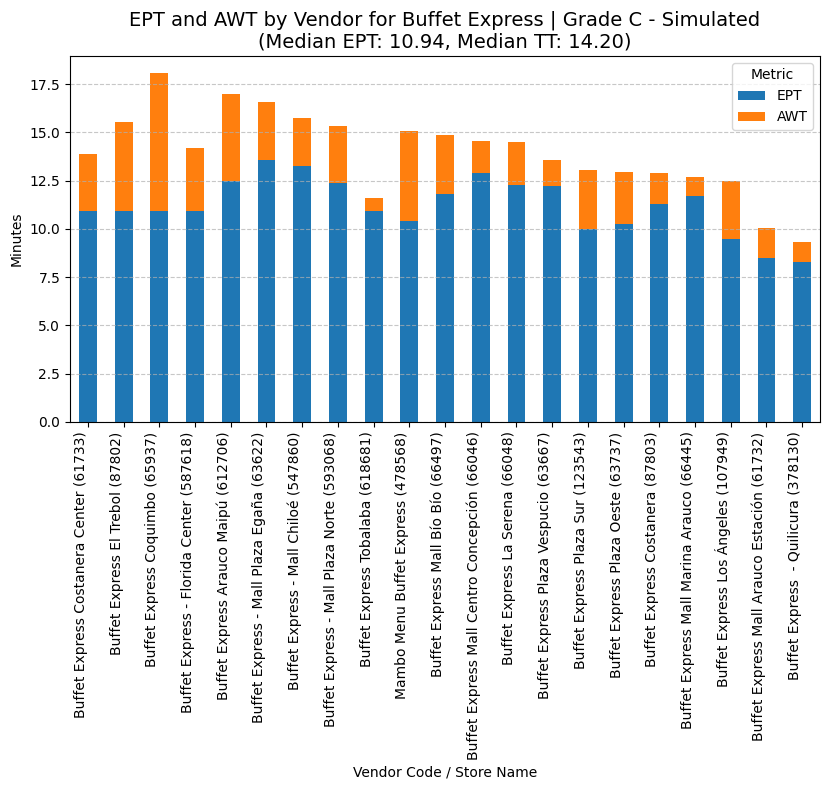

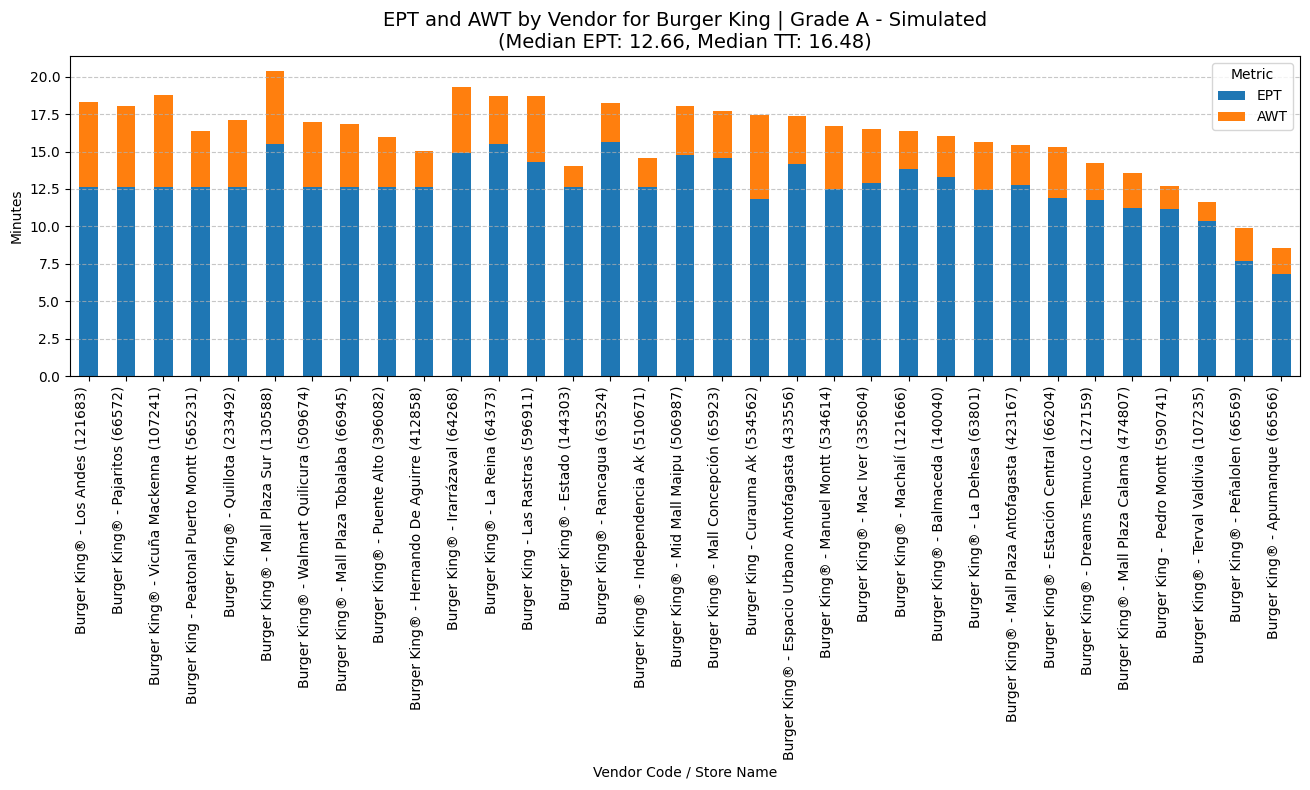

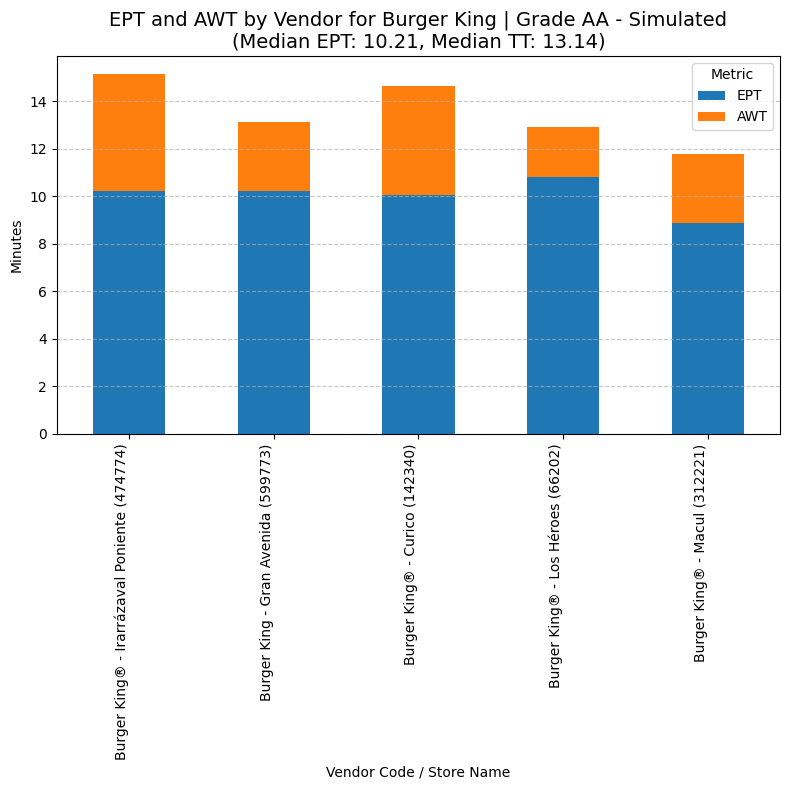

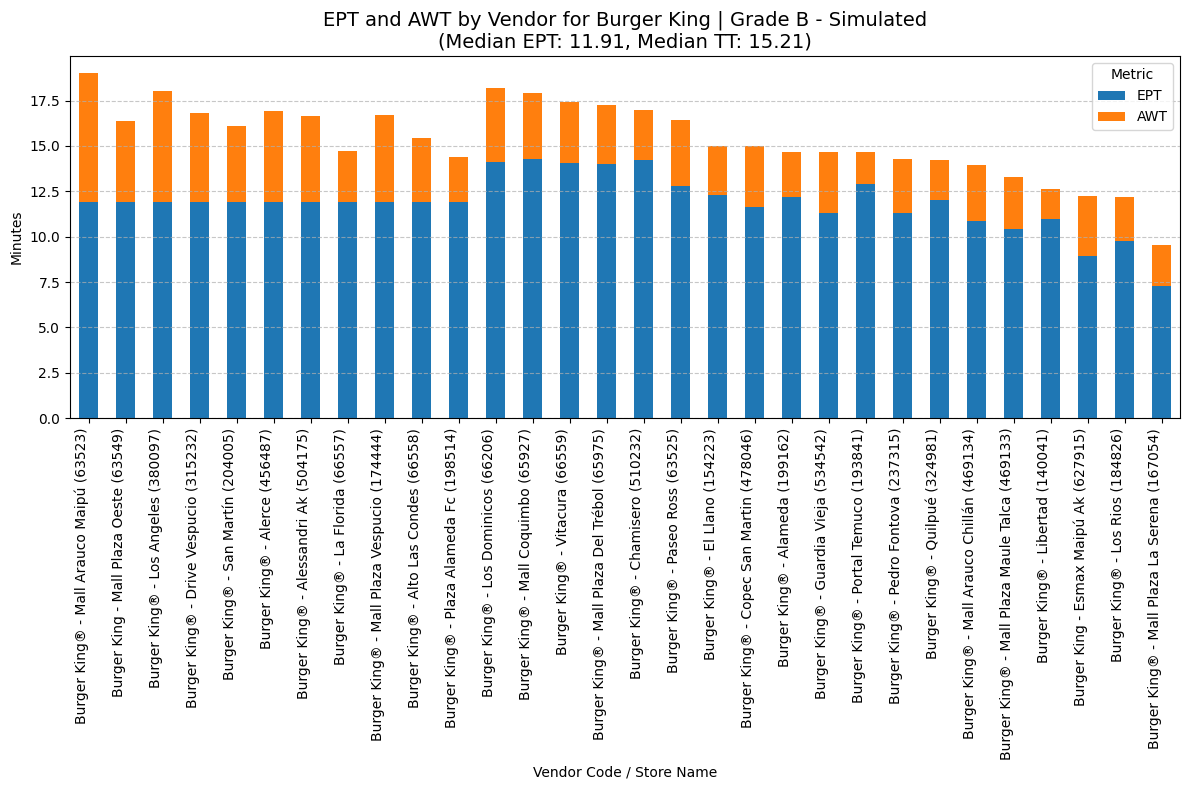

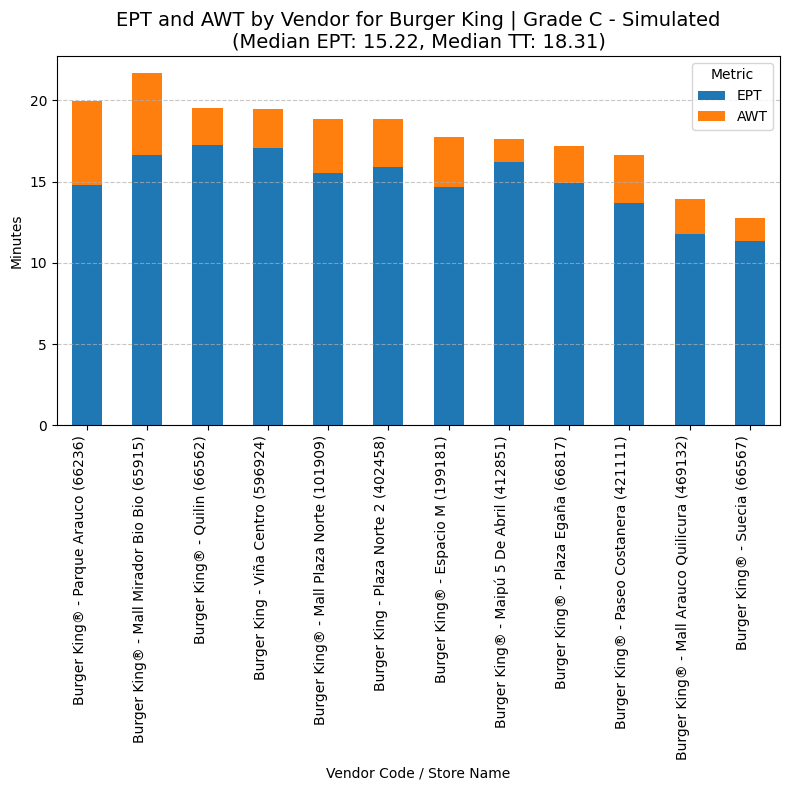

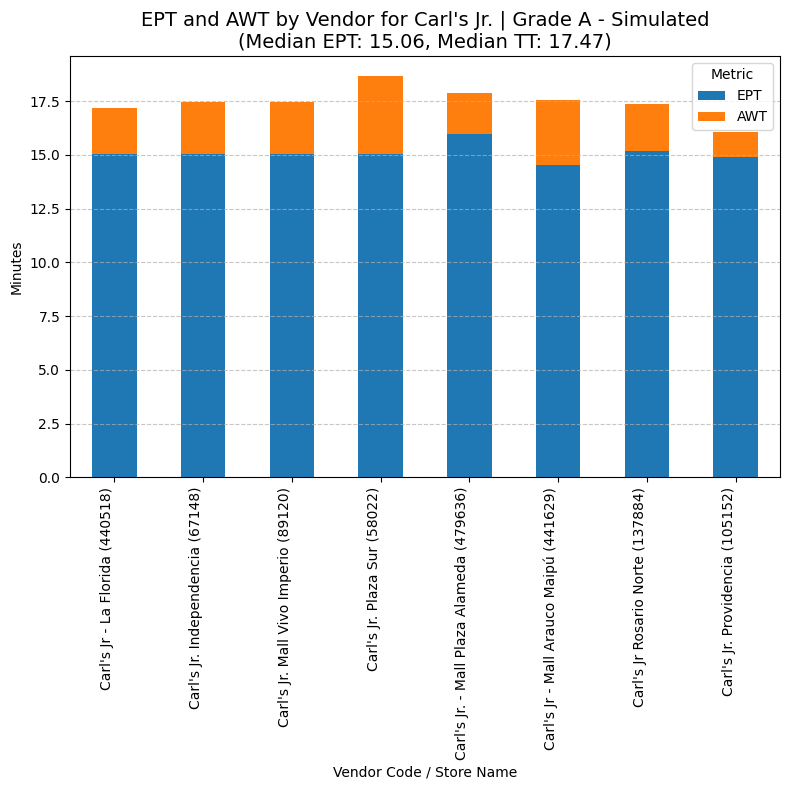

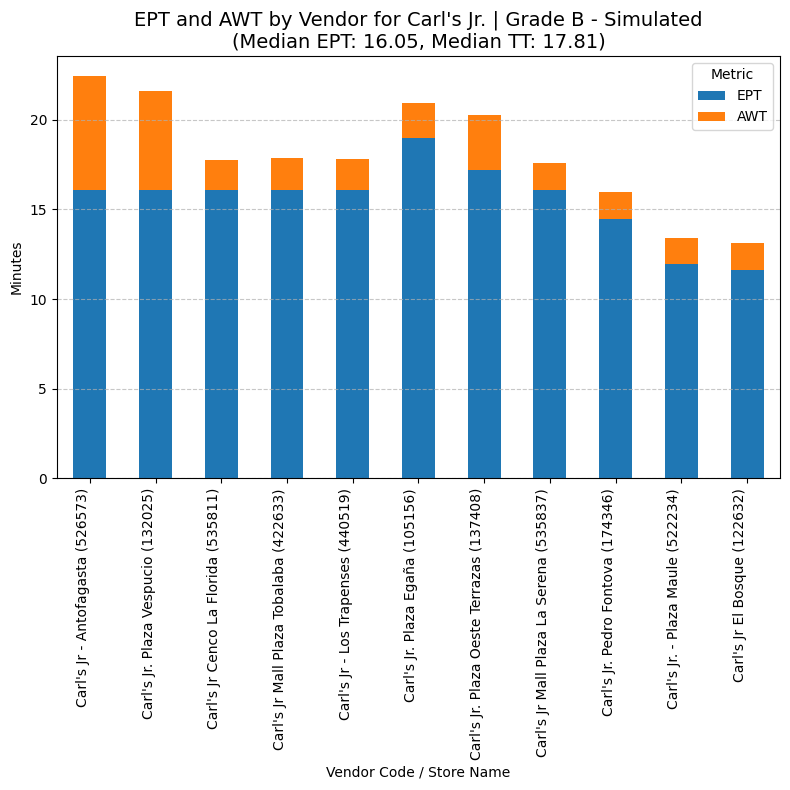

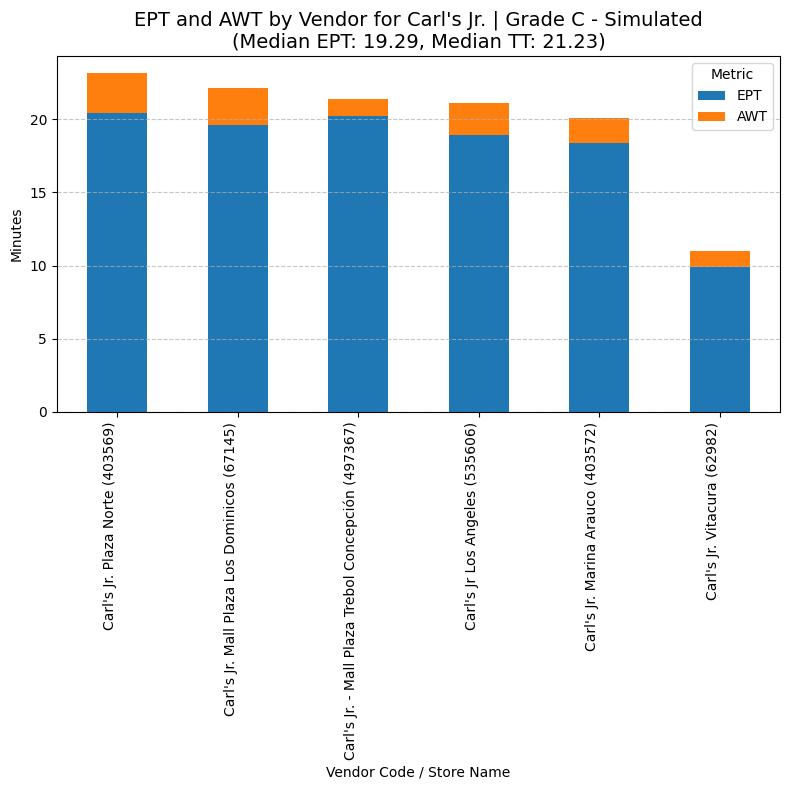

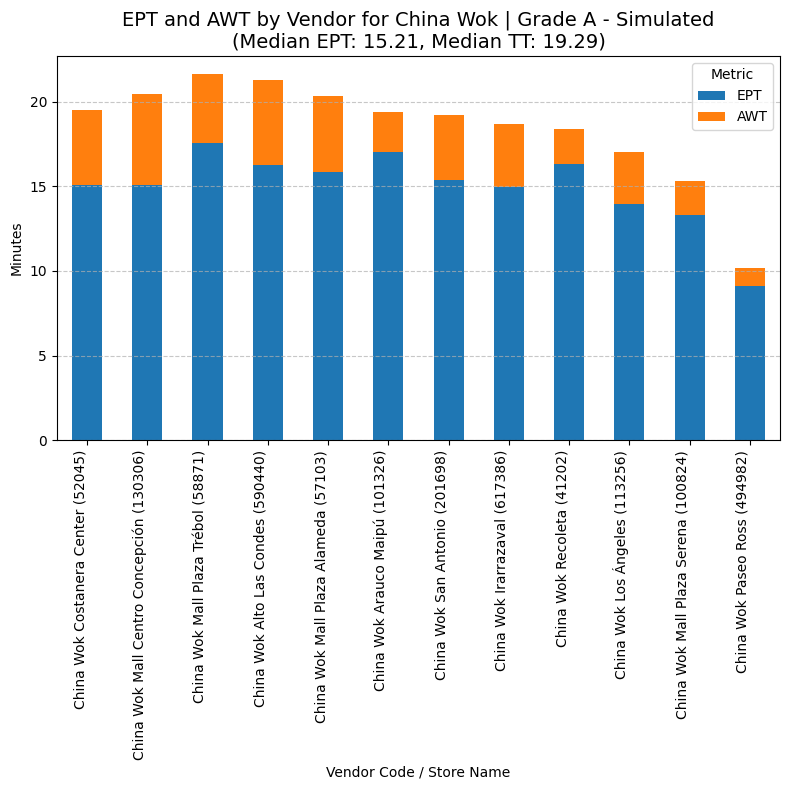

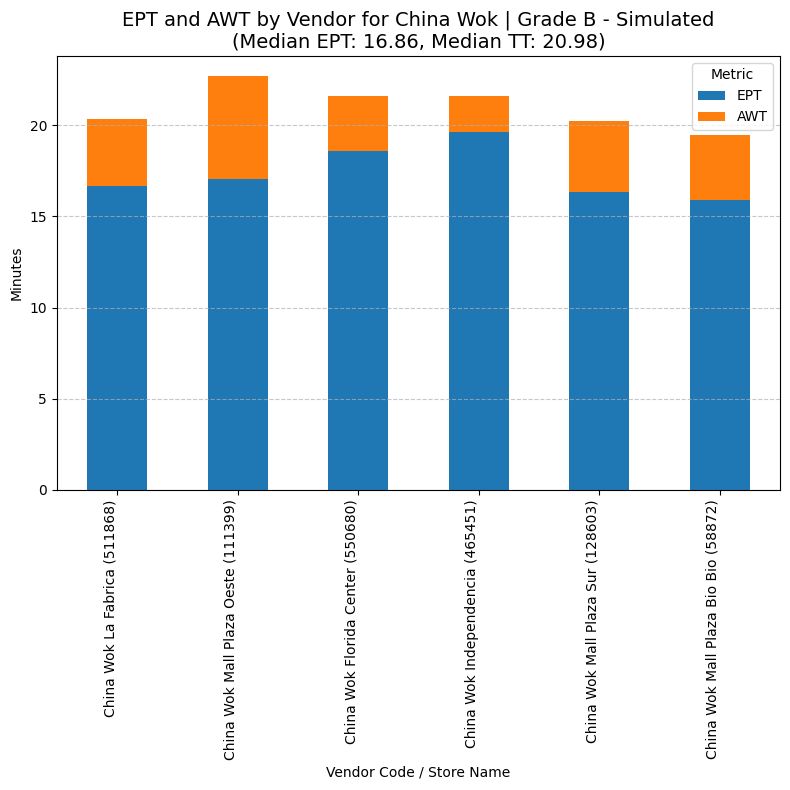

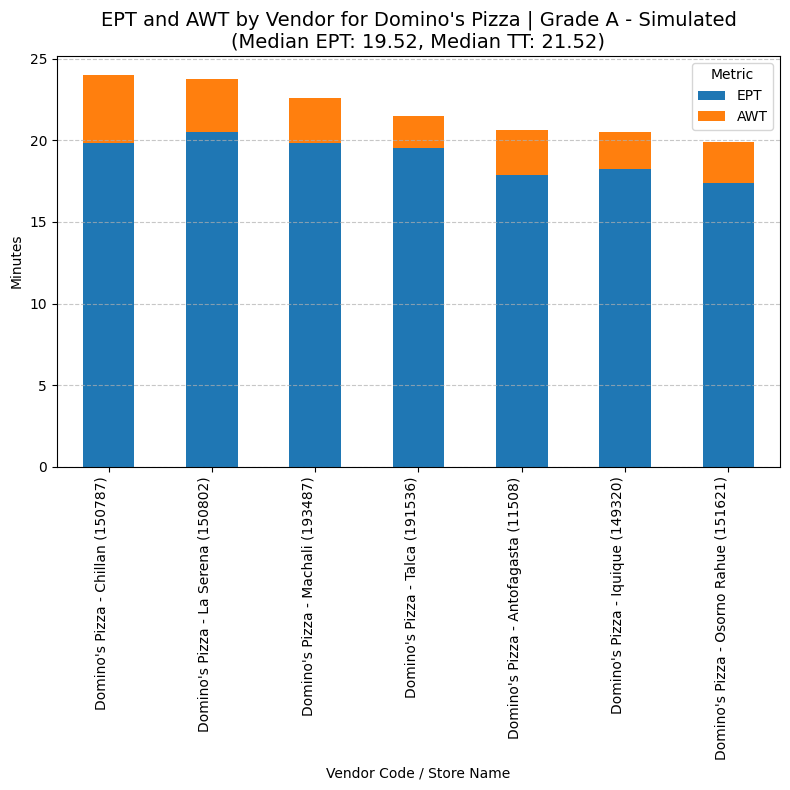

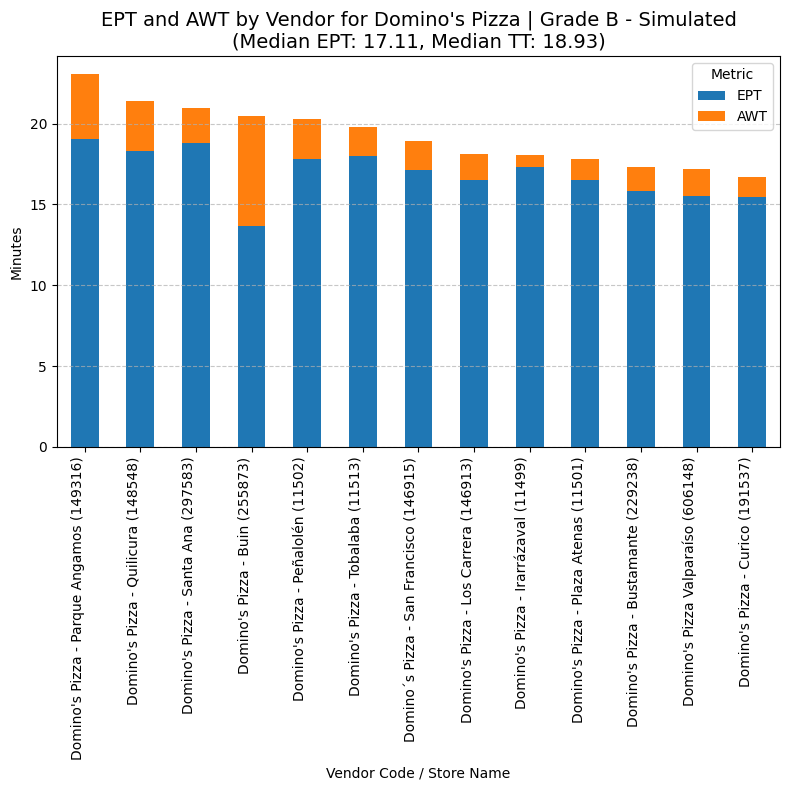

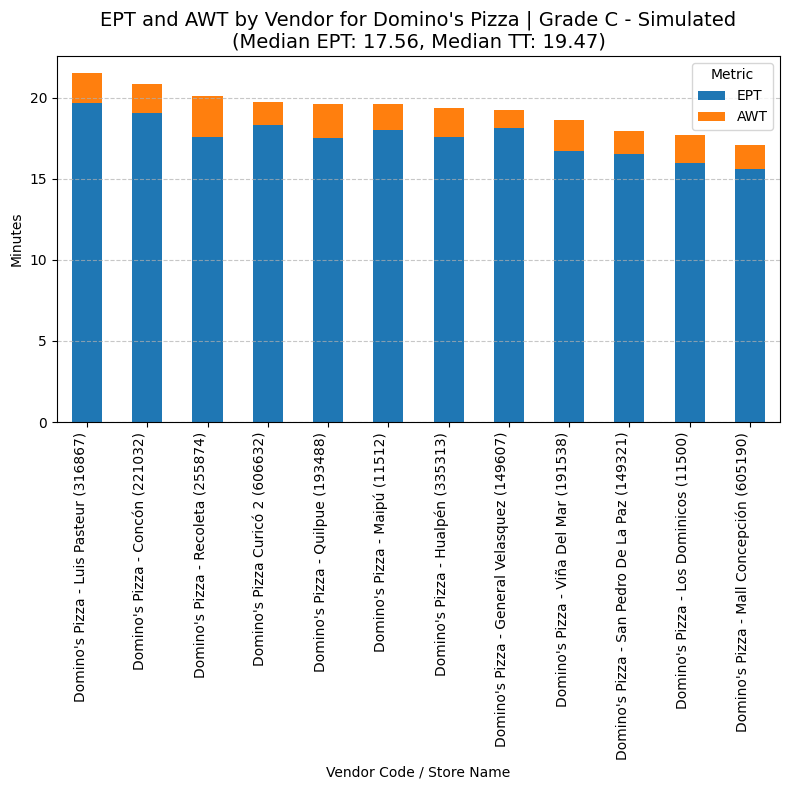

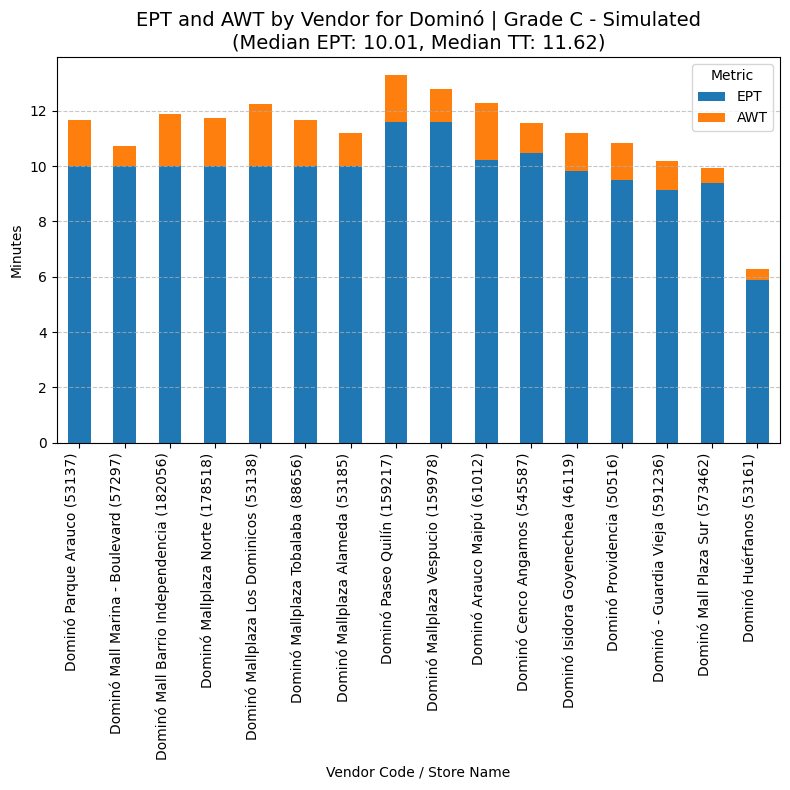

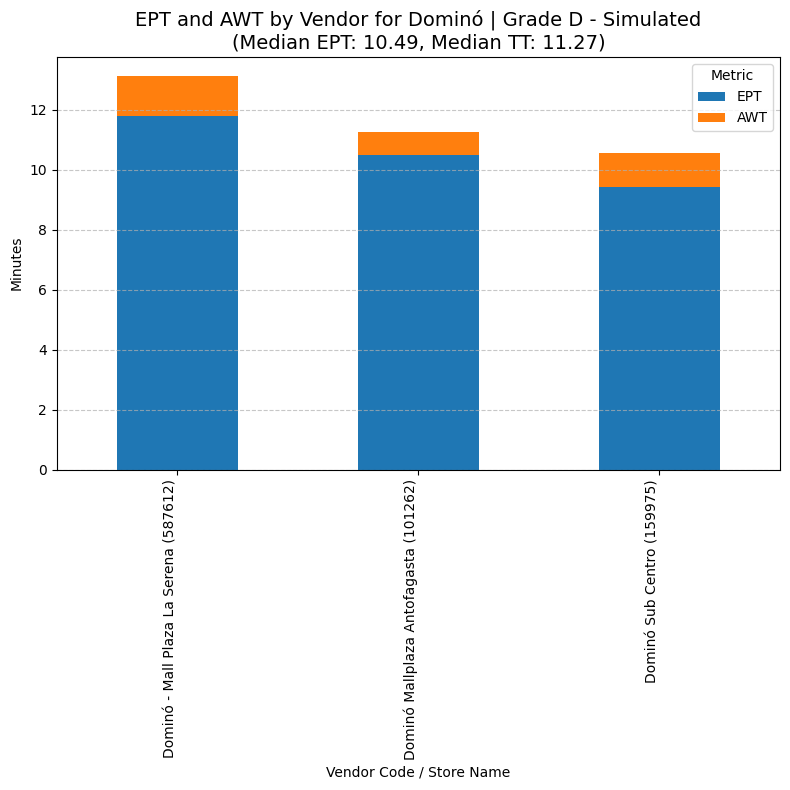

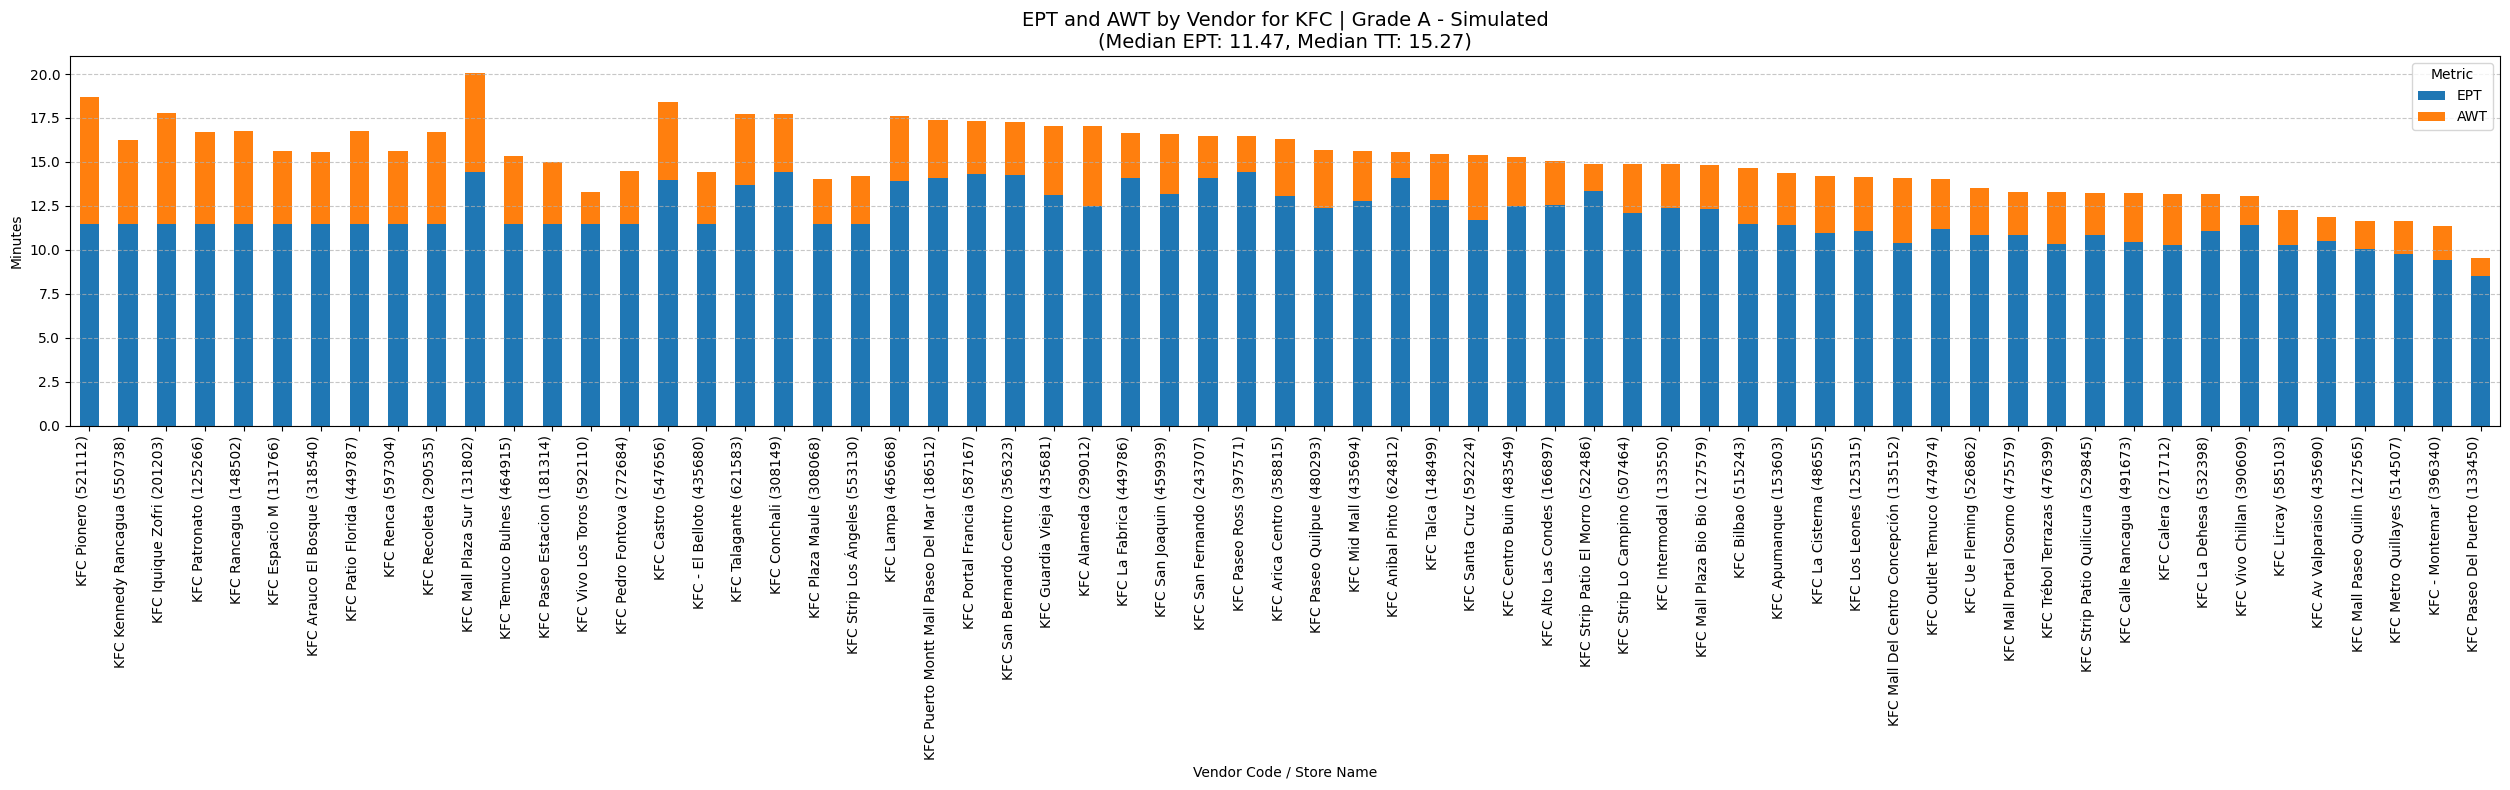

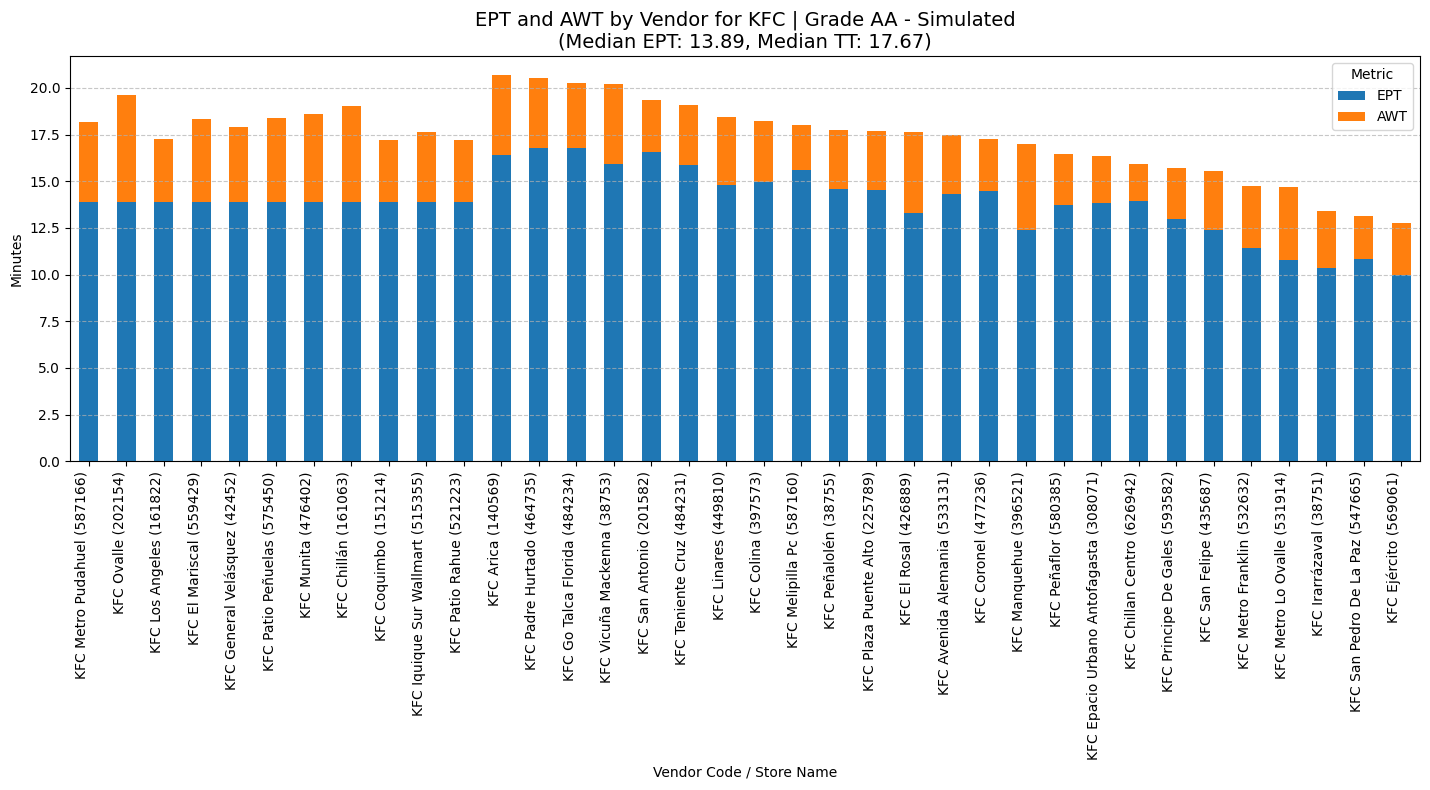

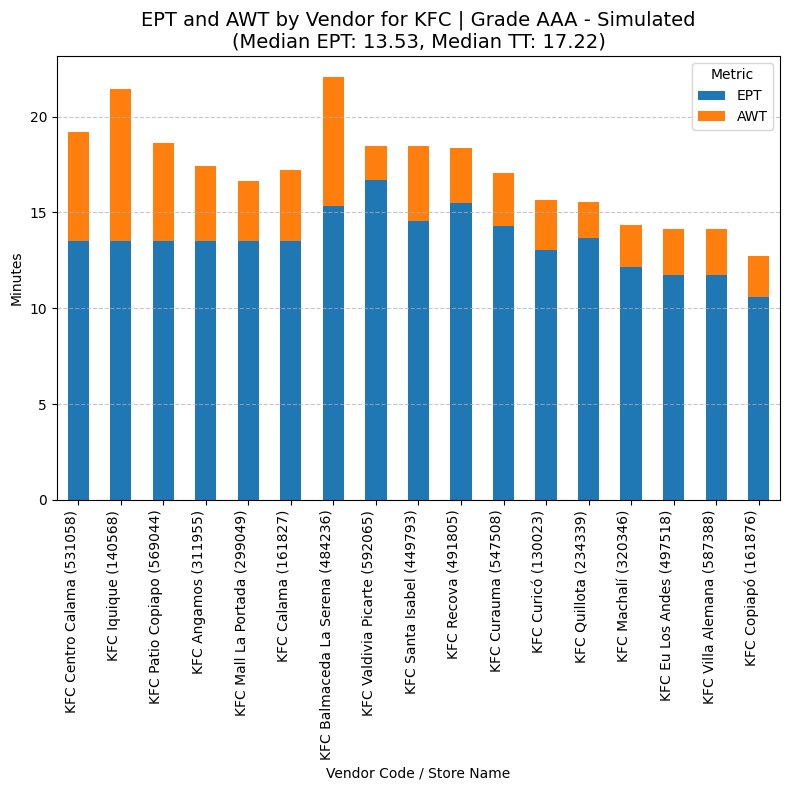

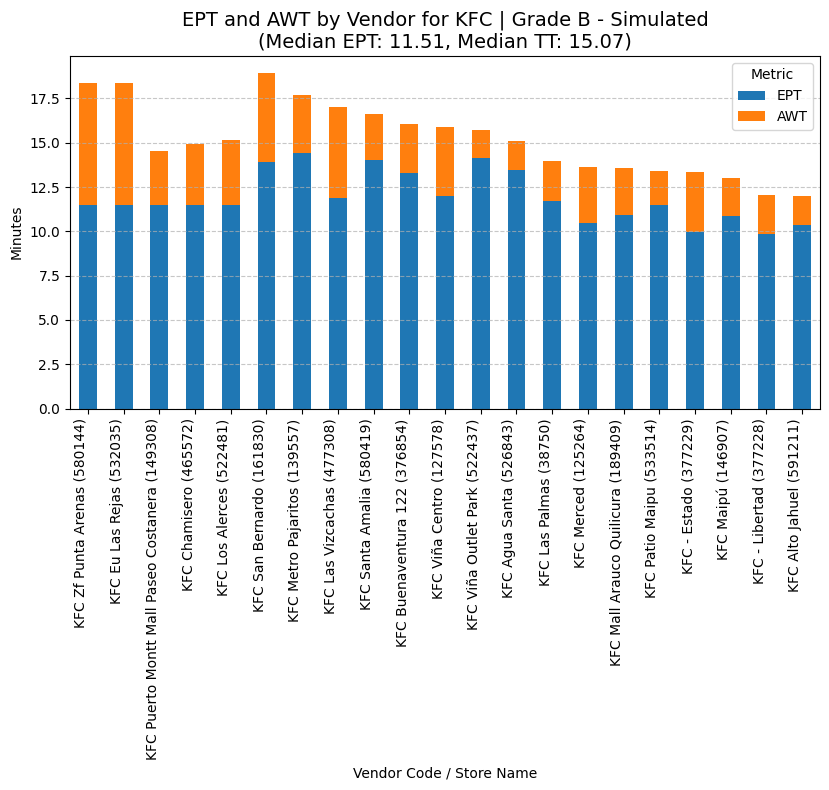

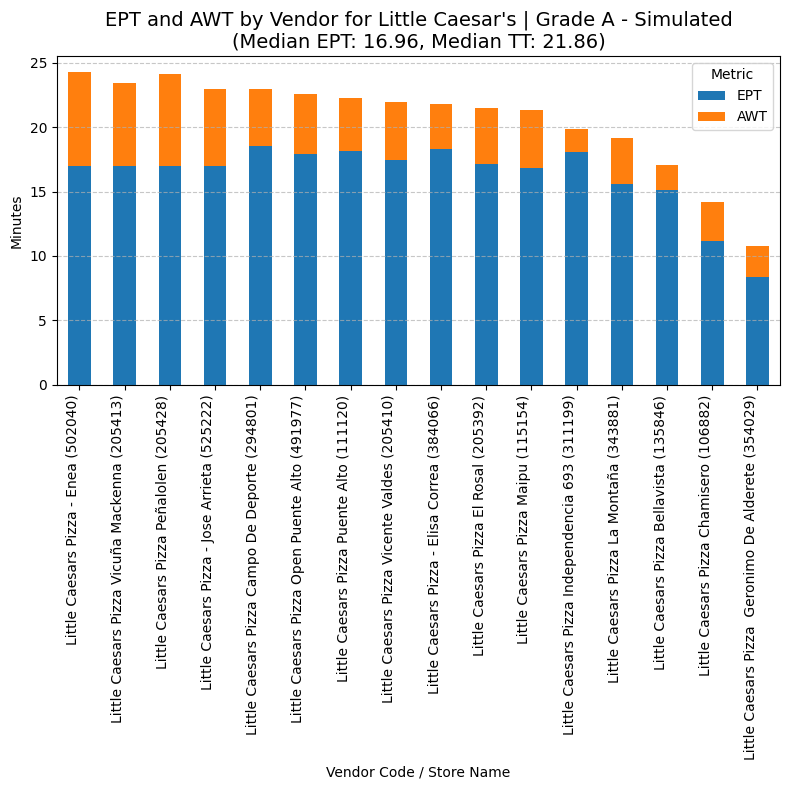

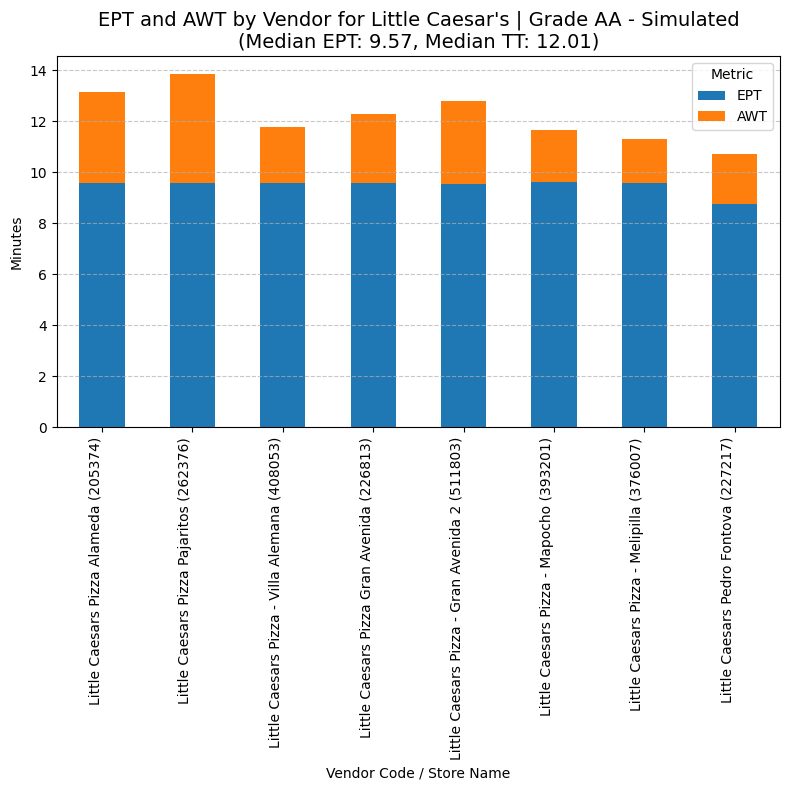

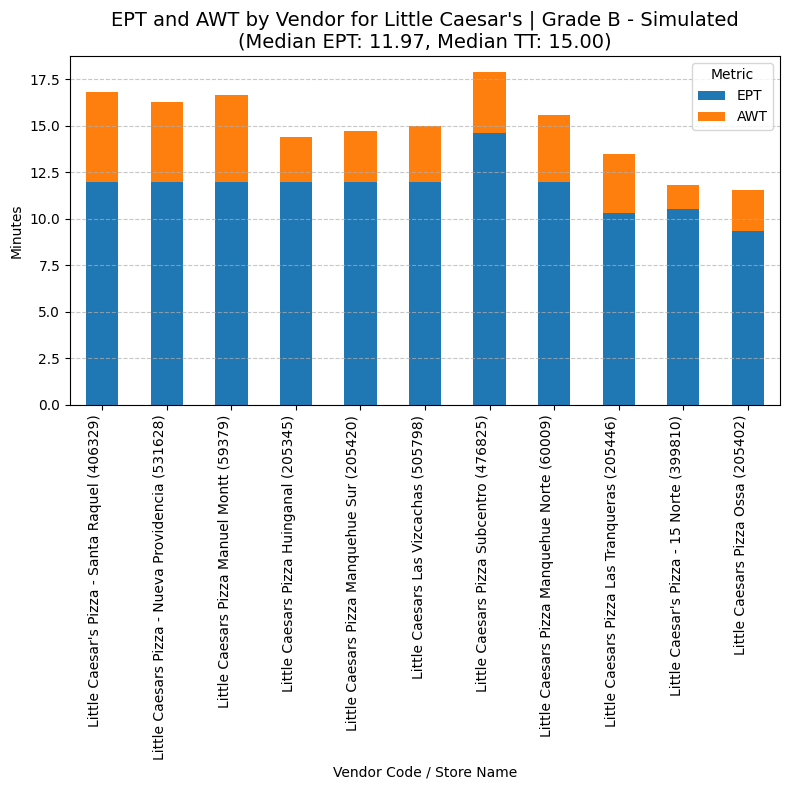

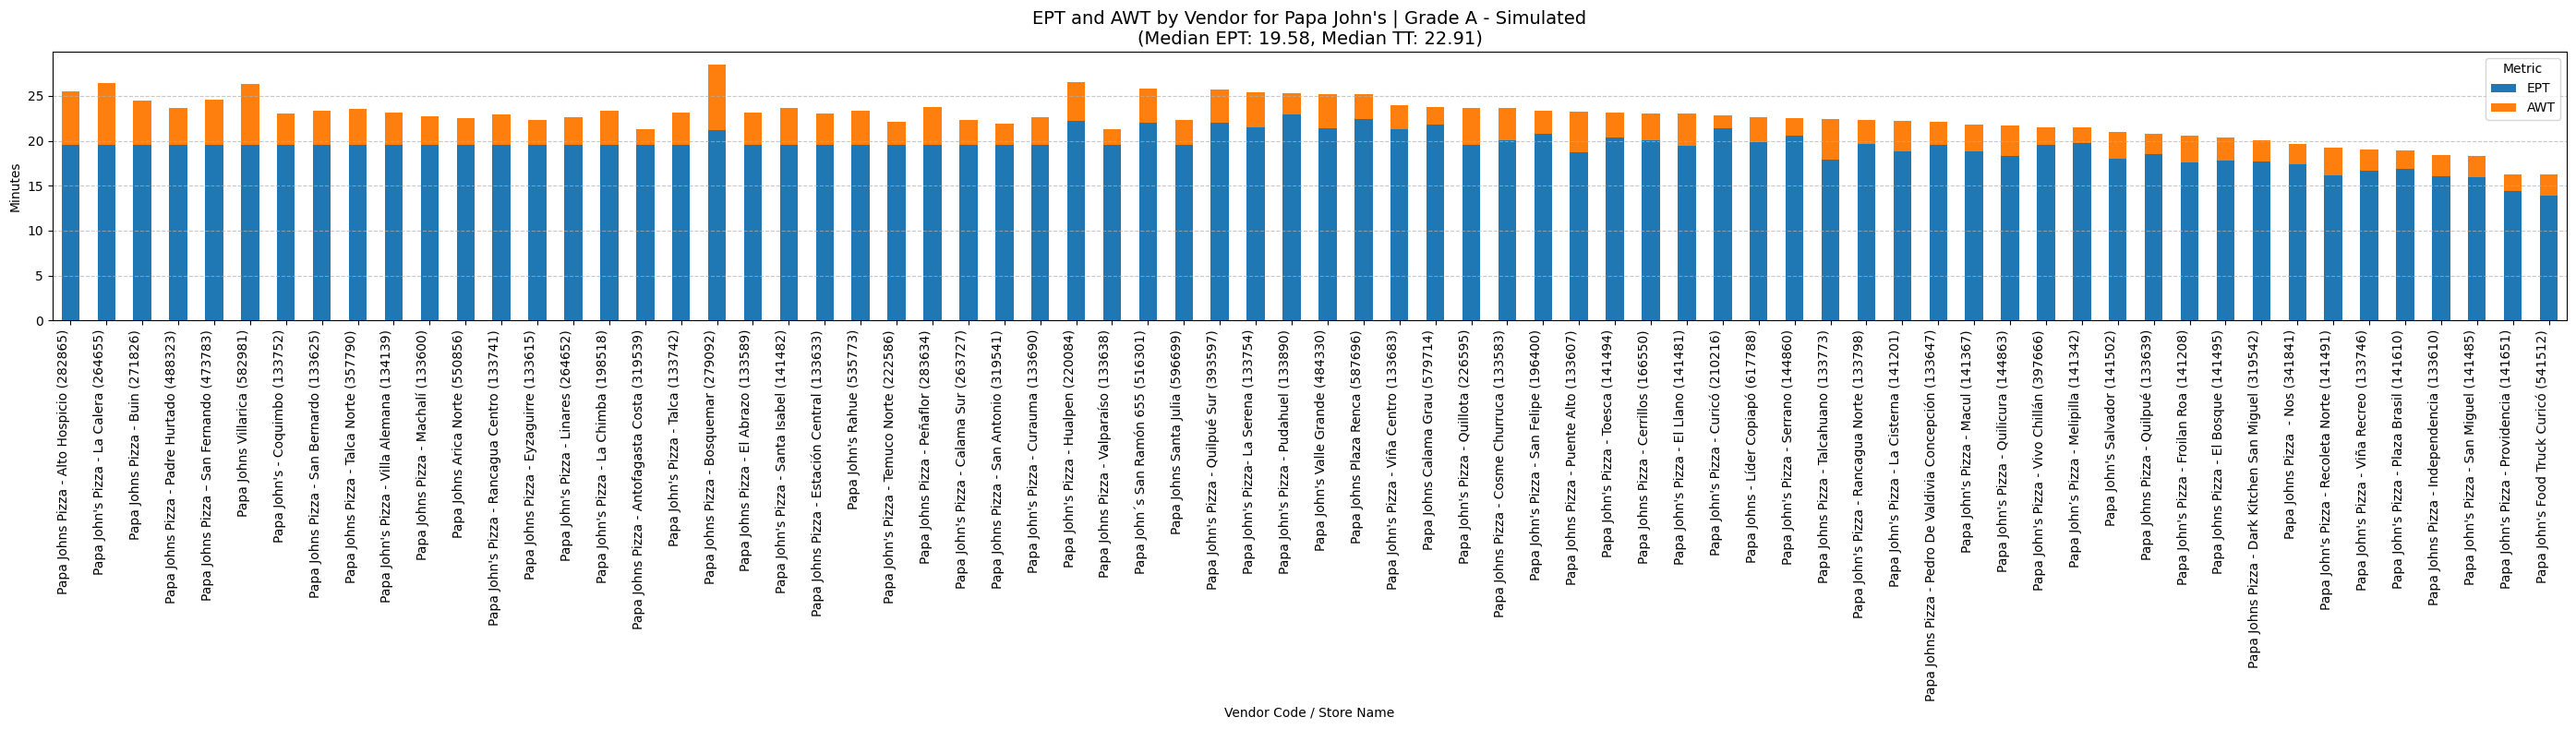

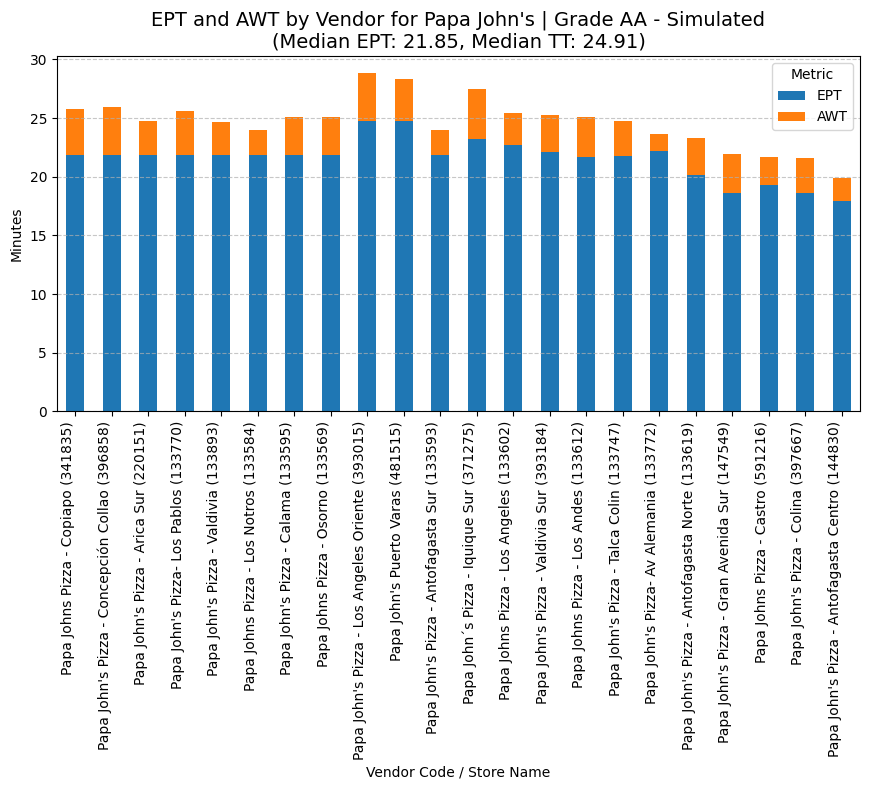

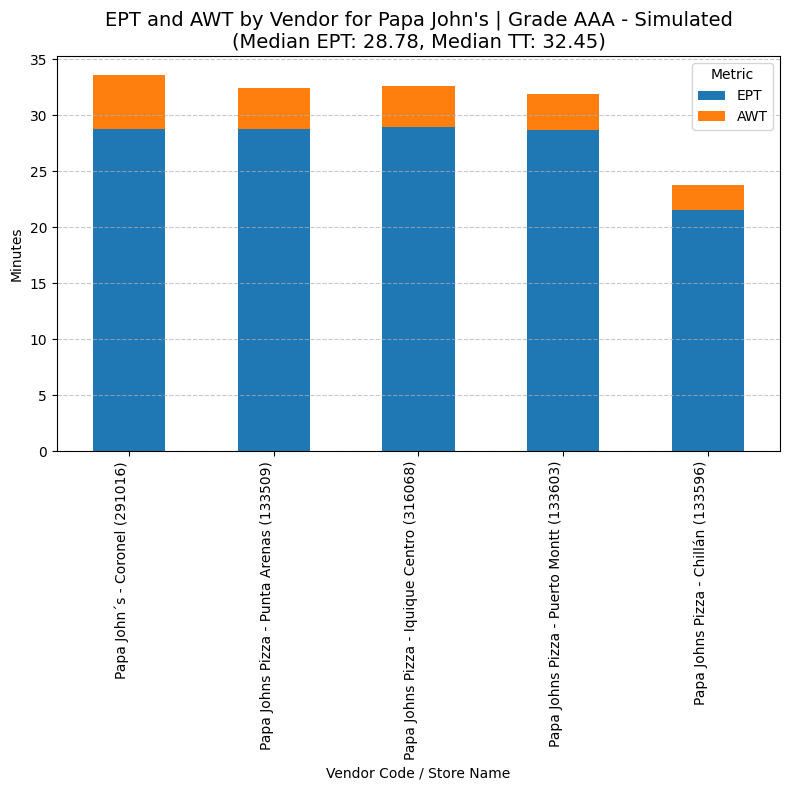

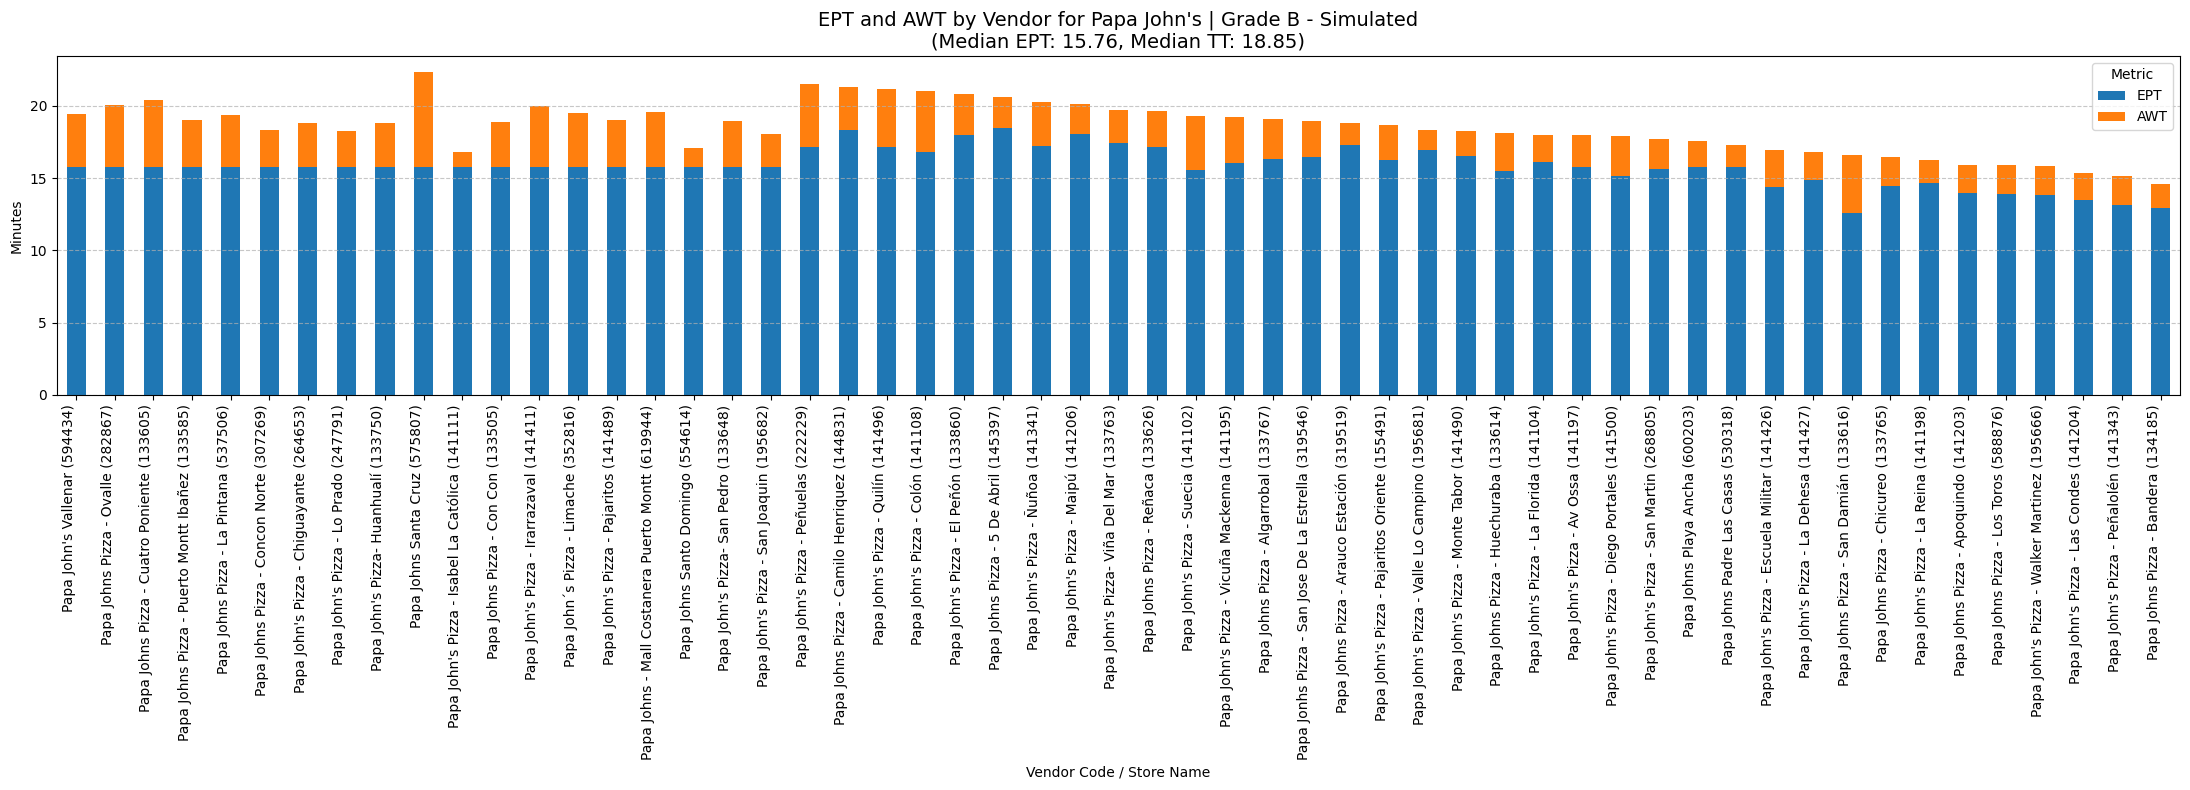

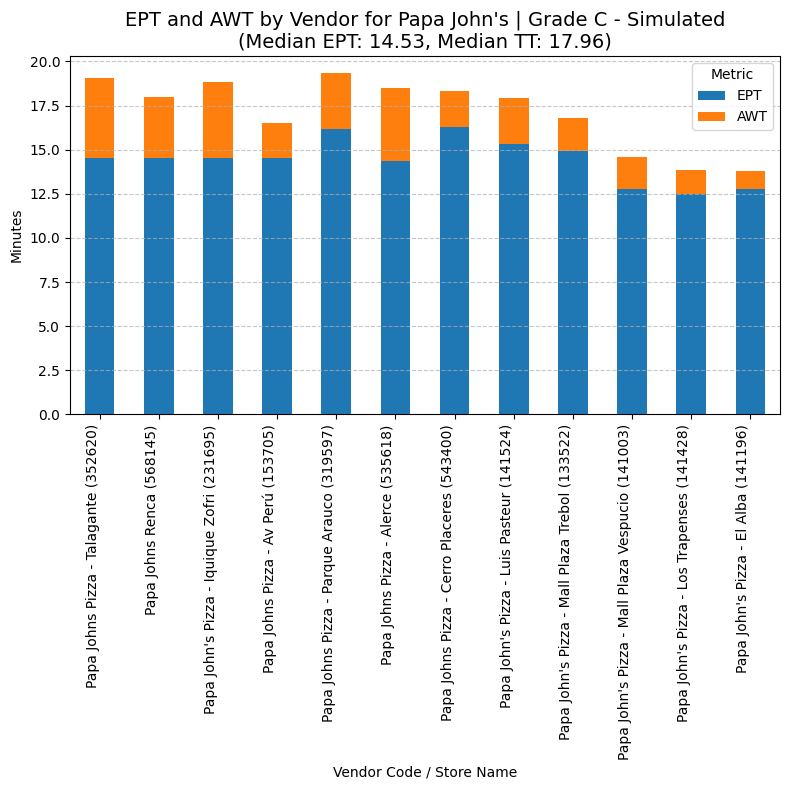

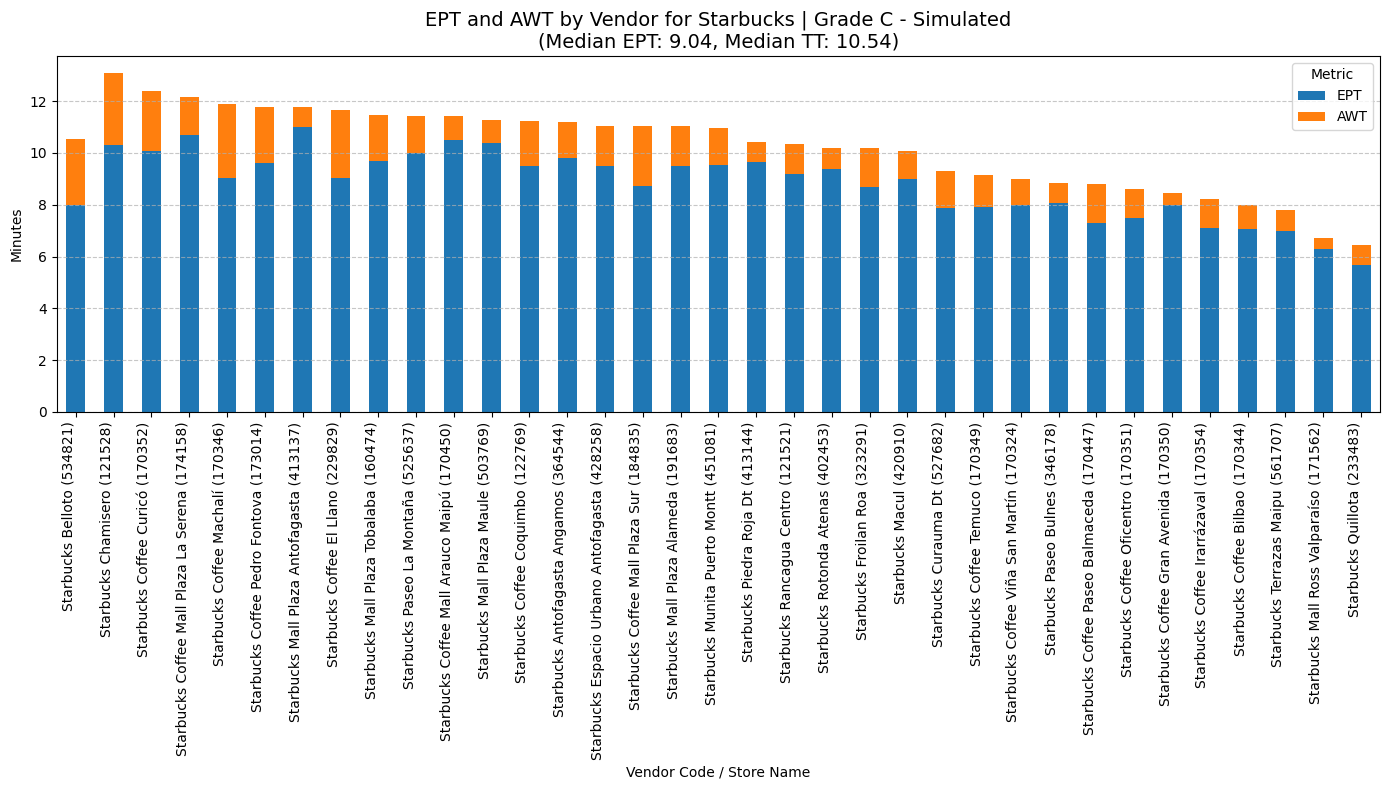

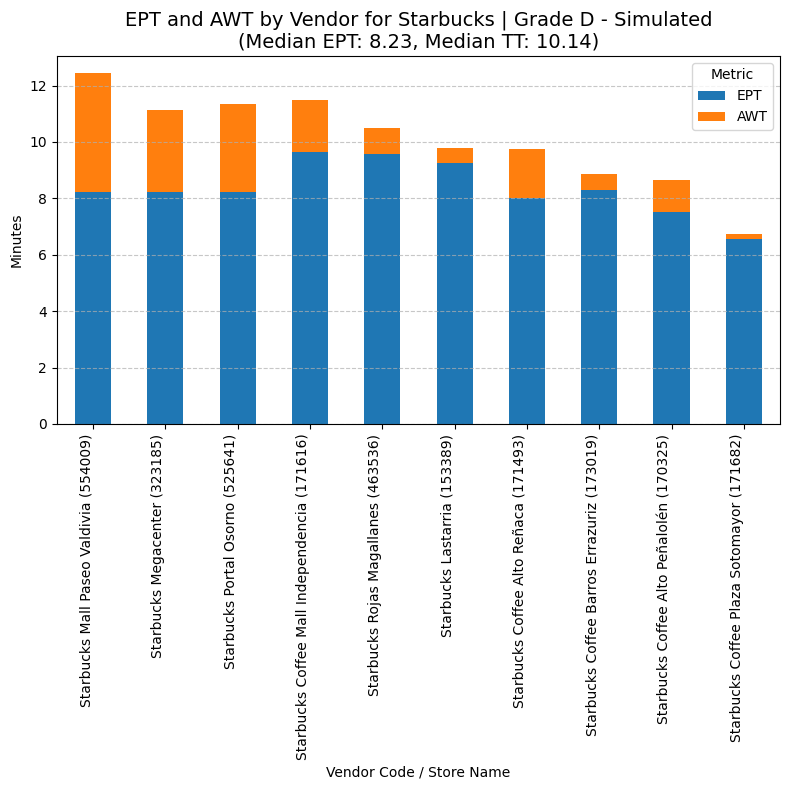

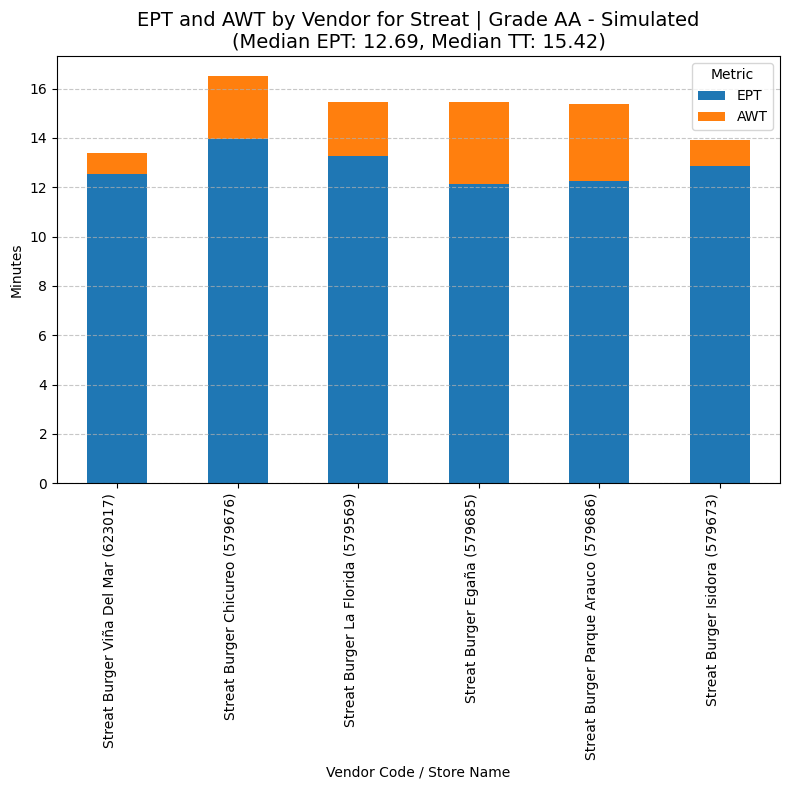

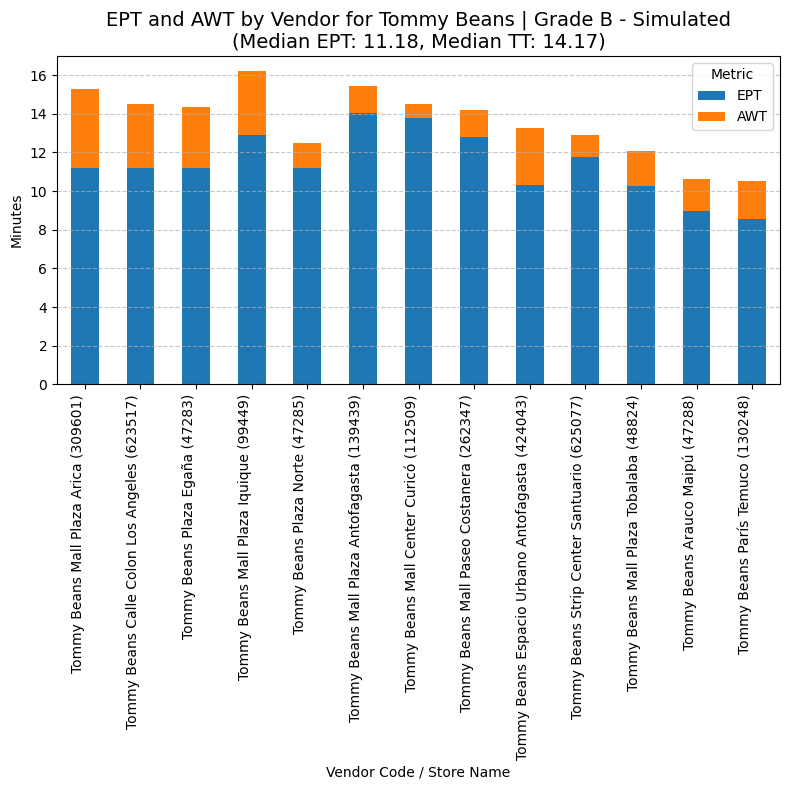

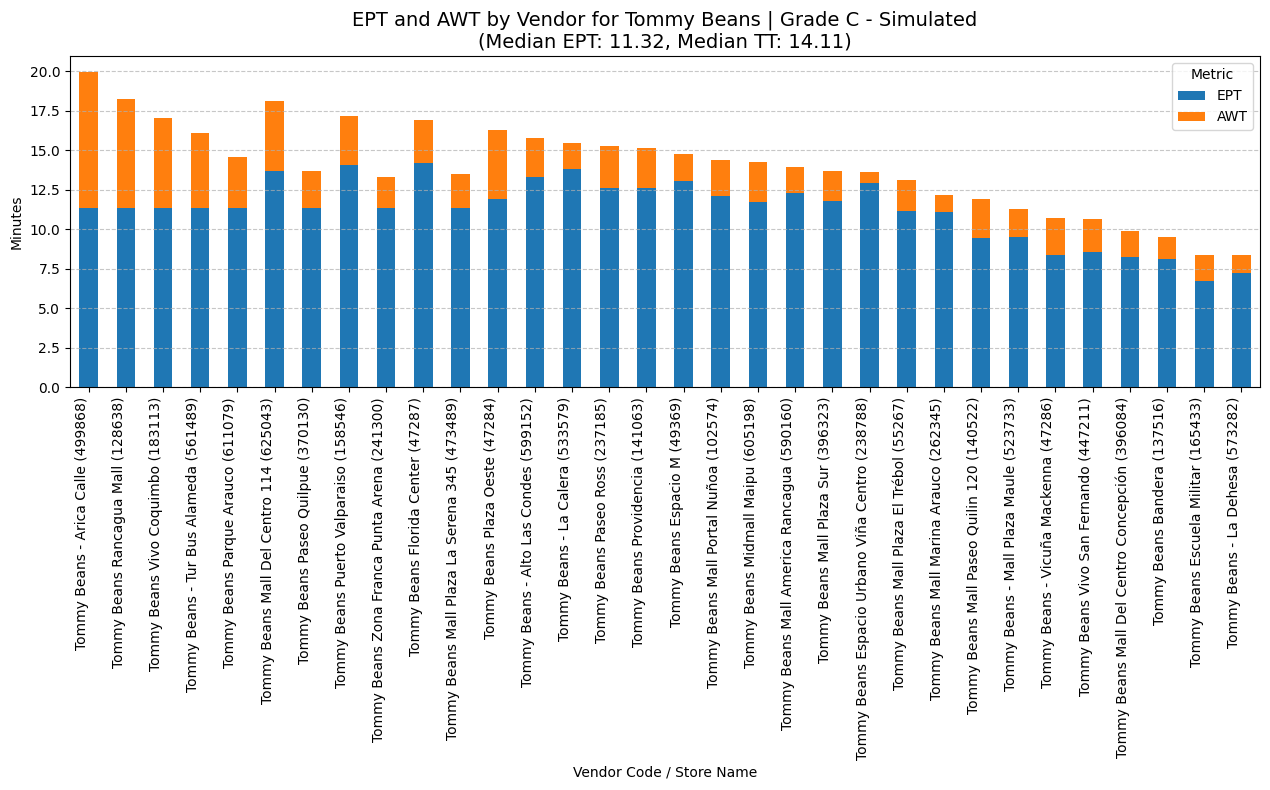

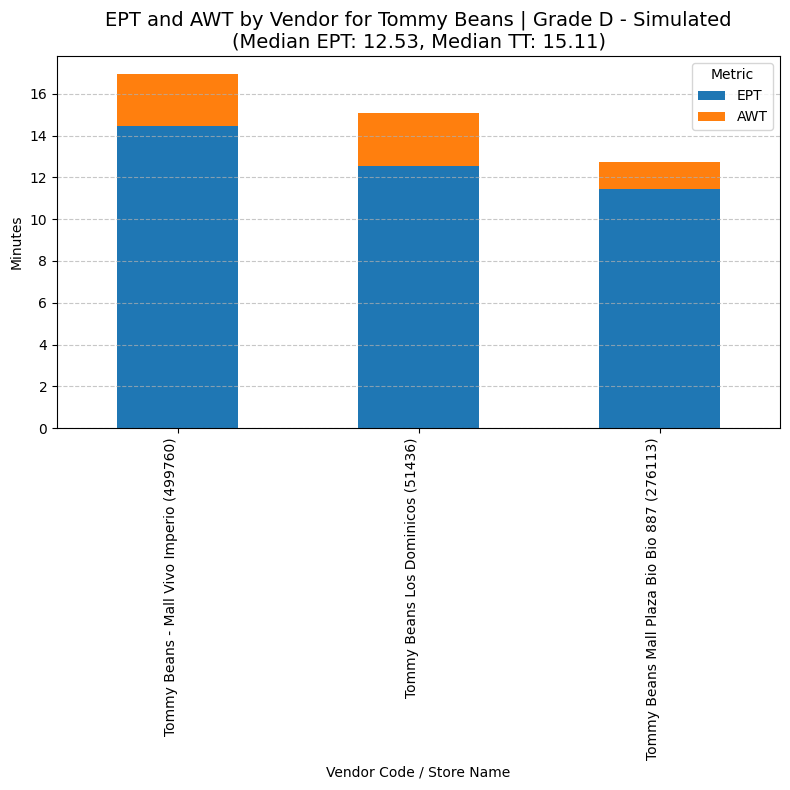

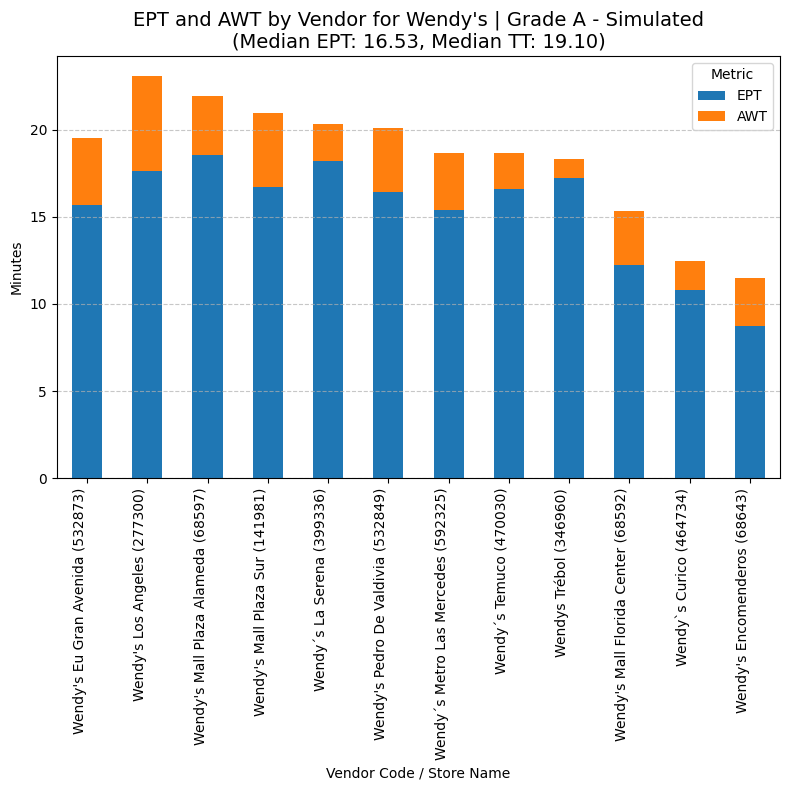

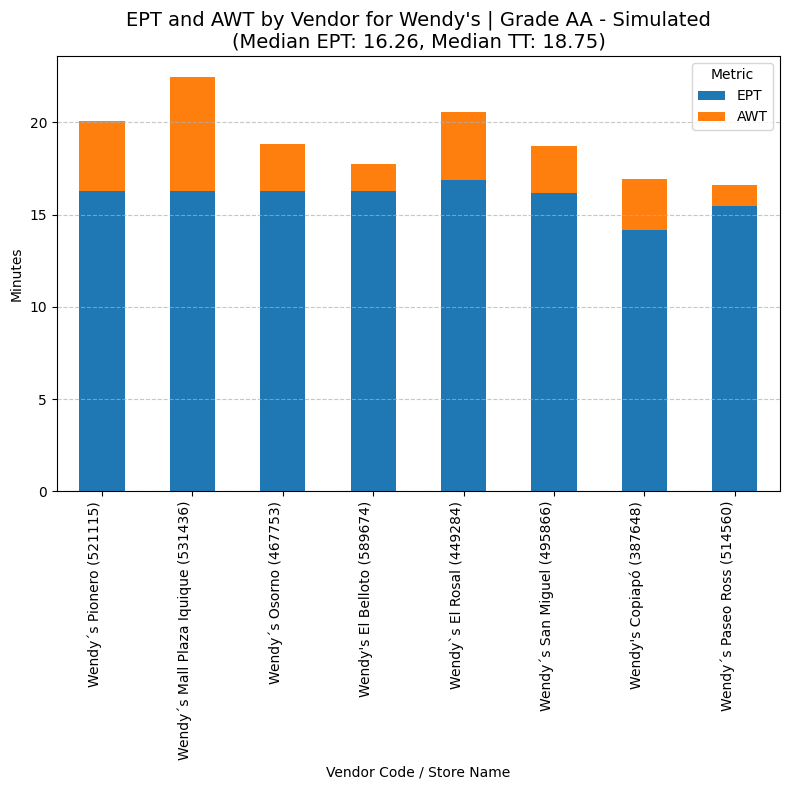

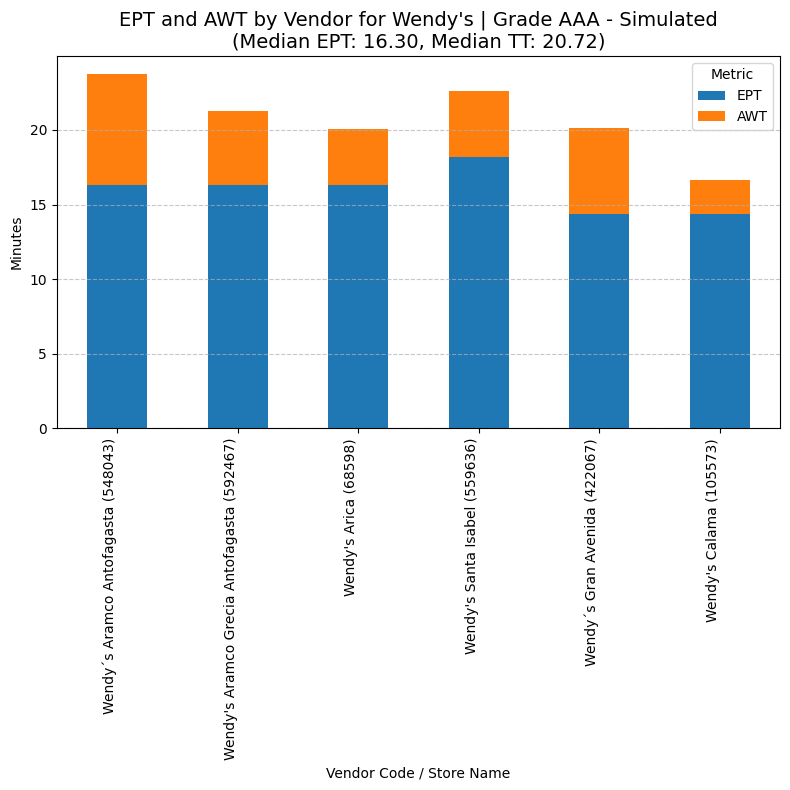

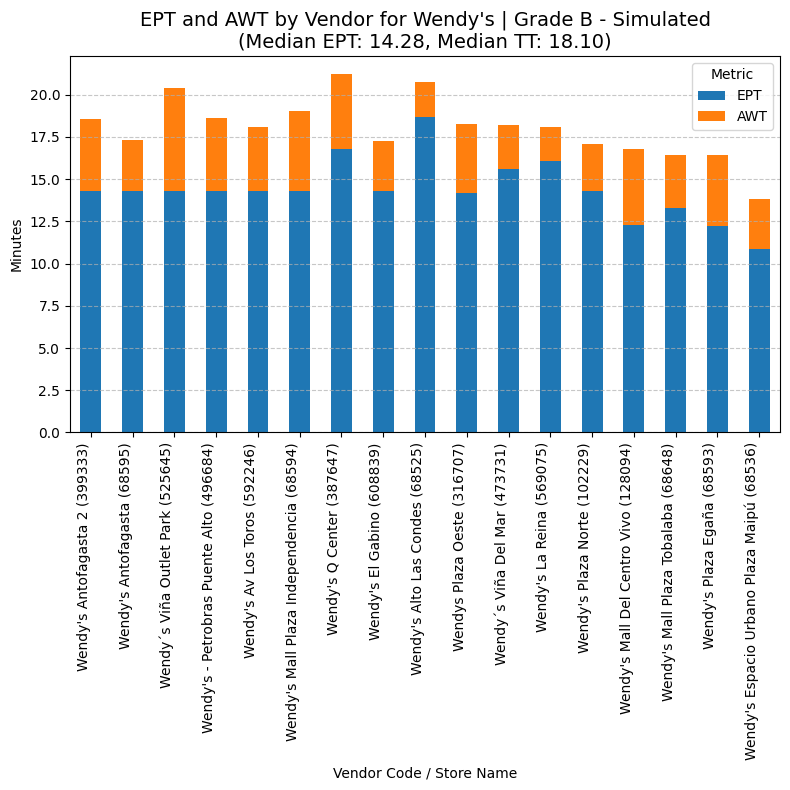

In [54]:
plot_ept_awt_by_franchise(
    df_30,
    order_df=df_grouped,
    ept_col="ept_new",
    awt_col="awt",
    title_suffix=" - Simulated",
    grade=USE_GRADE
)


### resumen general

normal

In [43]:
df_franchise_summary = franchise_summary(
    df_30,
    grade=USE_GRADE
)
display(df_franchise_summary.round(1))


,franchise_id,franchise_name,grade,is_selected,num_stores,total_orders,fir_ratio,avg_tt,avg_ept,avg_ept_new,diff,diff_pct
0,0011r00002VoIKjAAN,Buffet Express,C,True,1.0,89.0,0.0,19.7,16.2,12.2,-4.0,-24.5
1,0011r00002VoIKjAAN,Buffet Express,C,False,20.0,1865.0,0.0,15.0,11.7,11.7,0.0,0.0
2,0011r00002VoHvwAAF,Burger King,A,True,2.0,1148.0,0.0,25.3,20.0,14.6,-5.4,-27.1
3,0011r00002VoHvwAAF,Burger King,A,False,31.0,14108.0,0.0,17.5,13.8,13.8,0.0,0.0
4,0011r00002VoHvwAAF,Burger King,AA,True,2.0,1667.0,0.0,21.4,16.4,10.8,-5.6,-34.1
...,...,...,...,...,...,...,...,...,...,...,...,...
61,0011r00002VoHwCAAV,Wendy's,AA,False,6.0,3923.0,0.0,20.0,17.2,17.2,0.0,0.0
62,0011r00002VoHwCAAV,Wendy's,AAA,True,2.0,2344.0,0.0,39.2,30.7,19.5,-11.2,-36.4
63,0011r00002VoHwCAAV,Wendy's,AAA,False,4.0,4547.0,0.2,22.1,16.7,16.7,0.0,0.0
64,0011r00002VoHwCAAV,Wendy's,B,True,4.0,950.0,0.0,27.6,22.9,16.8,-6.2,-26.9


##### para reporte Slack

In [44]:
# En modo grade todos los totales y merges permanecen a nivel
# franchise + grade. Con USE_GRADE=False se conserva el flujo original.
summary_keys = ['franchise_id', 'franchise_name']
if USE_GRADE:
    summary_keys.append('grade')

df_total_stores = (
    df_franchise_summary
    .groupby(summary_keys, dropna=False)['num_stores']
    .sum()
    .reset_index(name='total_stores')
)

df_franchise_summary_filtered = (
    df_franchise_summary[
        df_franchise_summary['is_selected'] == True
    ]
    .copy()
    .rename(columns={'num_stores': 'selected_stores'})
)

df_franchise_summary_final = pd.merge(
    df_franchise_summary_filtered,
    df_total_stores,
    on=summary_keys,
    how='left',
    validate='one_to_one'
)

final_cols = ['franchise_name']
if USE_GRADE:
    final_cols.append('grade')
final_cols += [
    'selected_stores',
    'total_stores',
    'fir_ratio',
    'avg_ept',
    'avg_ept_new',
    'diff',
    'diff_pct'
]

df_franchise_summary_final = (
    df_franchise_summary_final[final_cols]
)

df_franchise_summary_final['diff_pct'] = (
    df_franchise_summary_final['diff_pct'] / 100
)

display(
    df_franchise_summary_final
    .query('diff_pct < -0.05')
    .sort_values(
        ['franchise_name'] + (['grade'] if USE_GRADE else [])
    )
    .round({
        'fir_ratio': 3,
        'avg_ept': 2,
        'avg_ept_new': 2,
        'diff': 2,
        'diff_pct': 3
    })
)


,franchise_name,grade,selected_stores,total_stores,fir_ratio,avg_ept,avg_ept_new,diff,diff_pct
0,Buffet Express,C,1.0,21.0,0.000,16.20,12.23,-3.98,-0.245
1,Burger King,A,2.0,33.0,0.000,19.98,14.57,-5.41,-0.271
2,Burger King,AA,2.0,5.0,0.005,16.38,10.80,-5.58,-0.341
3,Burger King,B,6.0,30.0,0.001,18.64,14.03,-4.60,-0.247
4,Burger King,C,1.0,12.0,0.000,20.65,15.72,-4.93,-0.239
5,Carl's Jr.,A,2.0,8.0,0.000,19.25,15.58,-3.67,-0.191
6,Carl's Jr.,B,2.0,11.0,0.000,25.26,18.99,-6.27,-0.248
7,China Wok,A,1.0,12.0,0.000,23.32,16.06,-7.26,-0.311
8,China Wok,B,1.0,6.0,0.000,23.26,17.80,-5.46,-0.235
9,Dominó,C,3.0,16.0,0.022,17.42,11.59,-5.84,-0.335


In [45]:
import os
from datetime import datetime

dest_folder = '/content/drive/MyDrive/lower ept y awt/results'
os.makedirs(dest_folder, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'df_franchise_summary_final{timestamp}.csv'

output_path = os.path.join(dest_folder, filename)

# df_30_clean = df_30_clean[df_30_clean['reduction']>0]
df_franchise_summary_final.to_csv(output_path, index=False)

print(f"df_franchise_summary_final exported to: {output_path}")
print(f"Rows exported: {len(df_franchise_summary_final):,}")

df_franchise_summary_final exported to: /content/drive/MyDrive/lower ept y awt/results/df_franchise_summary_final20260729_203651.csv
Rows exported: 29


##### export df_30 sheets

In [46]:
clean_cols = ['franchise_name']
if USE_GRADE:
    clean_cols.append('grade')
clean_cols += [
    'city_name',
    'vendor_code',
    'store_name',

    # Volumen y FIR
    'total_orders',
    'fir_ratio',
    'fir_avg',

    # EPT observado y EPT sin los minutos agregados por HDM
    'ept',
    'avg_ept_sin_hdm',

    # Resultado de la simulación
    'ept_reduction_pct',
    'ept_new'
]

df_30_clean = df_30[clean_cols].copy()

df_30_clean = df_30_clean.rename(columns={
    'total_orders': 'orders',
    'ept': 'old_ept',
    'ept_reduction_pct': 'reduction'
})

df_30_clean['diff'] = (
    df_30_clean['ept_new'] - df_30_clean['old_ept']
)

# Solo stores con reducción efectiva
df_30_clean = df_30_clean[df_30_clean['diff'] < 0].copy()

display(
    df_30_clean
    .sort_values('reduction', ascending=False)
    .round({
        'orders': 0,
        'fir_ratio': 3,
        'fir_avg': 2,
        'old_ept': 2,
        'avg_ept_sin_hdm': 2,
        'reduction': 3,
        'ept_new': 2,
        'diff': 2
    })
)


,franchise_name,grade,city_name,vendor_code,store_name,orders,fir_ratio,fir_avg,old_ept,avg_ept_sin_hdm,reduction,ept_new,diff
705,Tommy Beans,C,Arica,499868,Tommy Beans - Arica Calle,41.0,0.049,36.13,27.27,27.27,0.537,12.62,-14.65
378,Little Caesar's,AA,Santiago,205374,Little Caesars Pizza Alameda,1039.0,0.057,27.96,23.99,23.99,0.502,11.95,-12.04
258,KFC,A,Punta arenas,521112,KFC Pionero,504.0,0.000,NaN,22.05,22.05,0.406,13.10,-8.95
524,Papa John's,B,Vallenar,594434,Papa John's Vallenar,314.0,0.000,NaN,28.73,28.73,0.404,17.13,-11.60
319,KFC,AAA,Calama,531058,KFC Centro Calama,1603.0,0.000,NaN,25.49,25.49,0.399,15.31,-10.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,Papa John's,A,Villarrica,582981,Papa Johns Villarica,307.0,0.000,NaN,25.12,25.12,0.137,21.67,-3.45
406,Papa John's,A,Antofagasta,198518,Papa John's Pizza - La Chimba,522.0,0.000,NaN,25.12,25.12,0.137,21.67,-3.44
480,Papa John's,AA,Temuco,133770,Papa John's Pizza- Los Pablos,785.0,0.000,NaN,27.70,27.70,0.134,23.98,-3.72
473,Papa John's,AA,Concepcion,396858,Papa John's Pizza - Concepción Collao,938.0,0.000,NaN,27.61,27.61,0.132,23.98,-3.63


In [47]:
import os
from datetime import datetime

dest_folder = '/content/drive/MyDrive/lower ept y awt/results'
os.makedirs(dest_folder, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'df_30_clean_export_{timestamp}.csv'

output_path = os.path.join(dest_folder, filename)

# df_30_clean = df_30_clean[df_30_clean['reduction']>0]
df_30_clean.to_csv(output_path, index=False)

print(f"df_30_clean exported to: {output_path}")
print(f"Rows exported: {len(df_30_clean):,}")

df_30_clean exported to: /content/drive/MyDrive/lower ept y awt/results/df_30_clean_export_20260729_203653.csv
Rows exported: 111


nos quedamos solo con las selected para modificación

In [48]:
print(f'stores totales: {len(df_30)}')
df_30_mod = df_30[df_30['is_selected']==True]
print(f'stores a modificar: {len(df_30_mod)}')
# df_30_mod[['vendor_code','store_name', 'ept', 'ept_new']].head(5).round()

stores totales: 673
stores a modificar: 111


# Exportación final

In [49]:
# Exportar df_30_mod a CSV
output_file = "df_30_mod.csv"

df_30_mod.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"CSV exportado: {output_file}")

# Descargar automáticamente si estás usando Google Colab
from google.colab import files
files.download(output_file)

CSV exportado: df_30_mod.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>